In [1]:
import os
import random
import subprocess
import time
from copy import deepcopy

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib import patches
from matplotlib.collections import LineCollection
from scipy.stats import spearmanr
from sklearn.metrics import r2_score
from torch import Tensor
from torch_geometric.data import Data
from tqdm import tqdm

import barostat_parameters
import lammps_scripts
import network
from graph_utils import (
    LJInteractionParams,
    compute_angle_indices,
    compute_angles,
    get_correct_edge_vec,
    prepare_traj,
)
from ift import specialized_rollout_implicit
from itpo_weights import DatasetType, ITPOWeights
from pressure import compute_stress_curve, compute_stress_pressure
from simulator_SA_cpu_test import Model as VelocityModel
from torch_simulator_wLJ_64 import DifferentiableCompression64
from training_utils import freeze_normalizer
from utils import (
    calc_p_ratio_box_tensor,
    get_rollout,
    load_and_split_dataset,
    simulate_then_rollout,
    to_f32,
    to_f64,
    visualize_nu_disribution,
)


### Load Data

Loading data with max simulation length of 200...


test  data: 100%|██████████| 3/3 [00:00<00:00,  8.36it/s]



Preparing data...


test  data: 100%|██████████| 3/3 [00:00<00:00,  8.33it/s]



Train data: 5 sims.
Val data:   2 sims.
Test data:  3 sims.


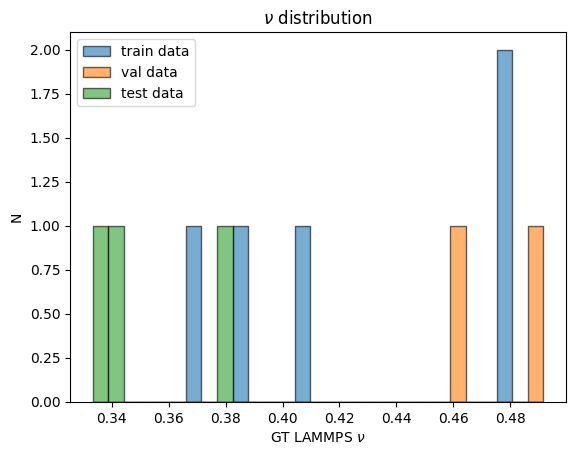

In [2]:
poisson_buckets = [
    {"min": 0.0, "max": 1.0, "count": 10},   # full range
]

dataset_type = DatasetType.LJNoisy

train_files, val_files, test_files = load_and_split_dataset(
    # registry_path="./data_mini/data_registry_mini.csv",
    # registry_path="./data/data_registry.csv",
    registry_path="./data/data_LJ_noisy_eps0.01_sigma1.0_cutoff1.122/data_registry.csv",
    target_data_type=dataset_type,
    possion_buckets=poisson_buckets,
    split_ratios=(0.5, 0.25, 0.25),
    seed=42
)

# Load actual data
data = {
    'train': {},
    'val' : {},
    'test' : {},
}

max_sim_len = 200
print(f"Loading data with max simulation length of {max_sim_len}...")
# stride = 5
for key in data:
    if key == 'train':
        data[key] = [torch.load(file, weights_only=False)[:max_sim_len] for file in tqdm(train_files, desc=f"{key:<5} data")]
        # data[key] = [torch.load(file, weights_only=False)[::stride] for file in tqdm(train_files, desc=f"{key:<5} data")]
    elif key == 'val':
        data[key] = [torch.load(file, weights_only=False)[:max_sim_len] for file in tqdm(val_files, desc=f"{key:<5} data")]
        # data[key] = [torch.load(file, weights_only=False)[::stride] for file in tqdm(val_files, desc=f"{key:<5} data")]
    elif key == 'test':
        data[key] = [torch.load(file, weights_only=False)[:max_sim_len] for file in tqdm(test_files, desc=f"{key:<5} data")]
        # data[key] = [torch.load(file, weights_only=False)[::stride] for file in tqdm(test_files, desc=f"{key:<5} data")]
    else:
        raise ValueError(f"Unexpected key in data dictionary: {key}. ")

print("\nPreparing data...")
for data_type, sims in data.items():
    prepared = []
    for sim in tqdm(sims, desc=f"{data_type:<5} data"):
        default_params = LJInteractionParams(epsilon=0.01, sigma=1.0, cutoff=1.122)
        prepared_sim = prepare_traj(sim, lj_params=default_params, calc_angles=False)
        prepared.append(prepared_sim)
    data[data_type] = prepared

print(f"\nTrain data: {len(data['train'])} sims.")
print(f"Val data:   {len(data['val'])} sims.")
print(f"Test data:  {len(data['test'])} sims.")

visualize_nu_disribution(data)


### Initialize pretrained models

In [3]:
mp_layers = 2
mlp = 3
hidden_size = 128
history = 3
device = "cpu"

init_graph = Data(x=torch.ones((100, history*2)), edge_attr=torch.ones((100, 7)))

models = {}

for i in range(87, 88, 1):
    model: VelocityModel = VelocityModel(init_graph, hidden_size, mp_layers, mlp).to(device)
    model_path = f"./LJ_trained_models/lj_noisy/MST/trained_model/checkpoint_epoch_{i}.pt"
    model.load_checkpoint(model_path)
    model = freeze_normalizer(model)
    model_name = f"h{3} mst epoch {i}"
    models[model_name] = model
    print(f"{i+1}. Model {model_name} from {model_path} .")

print(f"Dataset type: {dataset_type}")

Successfully loaded and migrated LEGACY checkpoint from ./LJ_trained_models/lj_noisy/MST/trained_model/checkpoint_epoch_87.pt
88. Model h3 mst epoch 87 from ./LJ_trained_models/lj_noisy/MST/trained_model/checkpoint_epoch_87.pt .
Dataset type: lj_noisy


### Testing models

#### Test model performance

In [ ]:
import pressure
import utils

%run utils.py
%run pressure.py

In [ ]:
def detach_to_cpu(x):
    if torch.is_tensor(x):
        return x.detach().cpu()
    return x

factors = [(sim[4].box_tensor[0] - sim[3].box_tensor[0]).item() for sim in data["test"]]
mean_factor = sum(factors)/len(factors)

num_steps = 100
model_results = {}
test_models = models

if dataset_type is DatasetType.NodeOptimized:
    barostat_config = barostat_parameters.node_optimizated
elif dataset_type is DatasetType.StiffOptimized:
    barostat_config = barostat_parameters.stiff_optimized
elif dataset_type is DatasetType.StiffAngles:
    barostat_config = barostat_parameters.stiff_angles
elif dataset_type is DatasetType.Noisy:
    barostat_config = barostat_parameters.noisy
elif dataset_type is DatasetType.LJNoisy:
    barostat_config = barostat_parameters.lj_noisy

name_len = max([len(n) for n in test_models])+1 

for model_name, model in test_models.items():
    model.eval()

    history = int(model_name[1])
    target_idx = num_steps + history + 1
    results = {
        "final_mse": [],
        "mse": [],
        "gt_p": [],
        "pred_p": [],
        "gt_box": [],
        "pred_box": [],
        "gt_stress": [],
        "pred_stress": [],
        "stress_curve_mse": [],
    }

    with torch.no_grad():
        for val_sim in tqdm(data['test'], desc=f"Model {model_name:<{name_len}}"):

            # This block computes dumping period (N MD steps in 1 dump step)        
            sim_strain = (val_sim[0].box.x - val_sim[-1].box.x) / val_sim[0].box.x
            assumed_rollout_length = int(sim_strain / 1e-5 / 0.01)
            dump_period = int(assumed_rollout_length / len(val_sim)) + 1

            barostat_config_current = deepcopy(barostat_config)
            barostat_config_current["default_skip"] = dump_period

            input_graphs = [g.cpu().detach() for g in val_sim[: history + 1]]

            # rollout = get_rollout(
            #     input_graphs=input_graphs,
            #     gnn_simulator=model,
            #     gnn_history=history,
            #     num_steps=num_steps,
            #     barostat_config=barostat_config_current,
            #     lj_params=default_params,
            #     device="cuda"
            # )

            rollout = simulate_then_rollout(
                starting_graph=input_graphs[0],
                gnn_simulator=model,
                gnn_history=history,
                barostat_config=barostat_config_current,
                lj_params=default_params,
                md_steps=(history * dump_period) + 1,
                rollout_steps=num_steps,
                device=device
            )

            rollout = [g.apply(detach_to_cpu) for g in rollout]

            # Compare Predicted Position vs Ground Truth Position
            pos_mse = torch.nn.functional.mse_loss(rollout[-1].pos.cpu(), val_sim[target_idx].to(device).pos.cpu()).item()
            results["final_mse"].append(pos_mse)
            pos_mse = [torch.nn.functional.mse_loss(rollout[i].pos.cpu(), val_sim[i].to(device).pos.cpu()).item() for i in range(len(rollout))]
            results["mse"].append(pos_mse)
            
            pred_p = calc_p_ratio_box_tensor(rollout).item()
            results["pred_p"].append(pred_p)
            gt_p = calc_p_ratio_box_tensor(val_sim[:target_idx+1]).item()
            results["gt_p"].append(gt_p)

            pred_box = [g.box_tensor.cpu() for g in rollout]
            results["pred_box"].append(pred_box)
            gt_box = [g.box_tensor.cpu() for g in val_sim[: len(rollout)]]
            results["gt_box"].append(gt_box)

            gt_stress = compute_stress_curve(val_sim[:target_idx+1], lj_cutoff=default_params.cutoff, sample_stride=1)
            results['gt_stress'].append(gt_stress.cpu().detach())
            pred_stress = compute_stress_curve(rollout, lj_cutoff=default_params.cutoff, sample_stride=1)
            results["pred_stress"].append(pred_stress.cpu().detach())
            stress_curve_mse = torch.nn.functional.mse_loss(pred_stress[:, 0], gt_stress[:, 0])
            results["stress_curve_mse"].append(stress_curve_mse.cpu().detach())

    model_results[model_name] = results

#### Parity plots for GT and predicted $\nu$

In [ ]:
params = {
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 6,
    'lines.markersize': 4,
    'figure.figsize': (3.33, 3.33),
    'figure.dpi': 200,
    'font.family': 'serif',
}
plt.rcParams.update(params)

fig, ax = plt.subplots(1, 1, layout="constrained")

line = (min(results["gt_p"]) - 0.05, max(results["gt_p"]) + 0.05)
ax.plot(line, line, color="black", linewidth=1, linestyle='--')

for model_name, results in model_results.items():

    r2 = r2_score(results['gt_p'], results['pred_p'])
    res = spearmanr(results["gt_p"], results["pred_p"])
    sp = res.statistic
    
    label_text = f"Model {model_name}: $R^2={r2:.6f}$, SP={sp:.3f}"
    ax.scatter(results["gt_p"], results["pred_p"], label=label_text)
    
ax.legend(frameon=False, loc='best')
ax.set_xlabel(r"$\nu_{gt}$")
ax.set_ylabel(r"$\nu_{pred}$")
# ax.set_ylim(-0.4, 0.4)

plt.show()


#### MSE as a function of strain

In [ ]:
rand_sim = random.randint(0, len(results['mse'])-1)
for model_name, results in model_results.items():
    plt.plot(results["mse"][rand_sim], label=f"Model {model_name}")

plt.legend()
plt.yscale('log')
plt.title(f"Sim {rand_sim}")
plt.xlabel('Rollout step')
plt.ylabel('Position MSE')
plt.show()

In [ ]:
rand = random.randint(0, len(results) - 1)

fig, ax = plt.subplots(2, 2, layout="constrained", figsize=(4, 4), sharex=True)

any_key = random.sample(sorted(model_results.keys()), k=1)[0]
box_y_true = [model_results[any_key]["gt_box"][rand][i][1].item() for i in range(1, len(rollout) - 1)]
box_x_true = [model_results[any_key]["gt_box"][rand][i][0].item() for i in range(1, len(rollout) - 1)]

stress_gt = results["gt_stress"][rand]

ax[0][0].plot(box_y_true, label="$L_y$ GT")
ax[1][0].plot(box_x_true, label="$L_x$ GT")
ax[0][1].plot(stress_gt[:, 1], label=r"$\sigma_{yy}$ GT")
ax[1][1].plot(stress_gt[:, 0], label=r"$\sigma_{xx}$ GT")


for model_name, results in model_results.items():

    box_y_roll = [results["pred_box"][rand][i][1].item() for i in range(1, len(rollout) - 1)]
    box_x_roll = [results["pred_box"][rand][i][0].item() for i in range(1, len(rollout) - 1)]

    stress_roll = results["pred_stress"][rand]

    ax[0][0].plot(box_y_roll, label=model_name)
    ax[0][0].set_ylabel(r"$\hat{L_y}$")
    ax[0][0].legend()

    ax[1][0].plot(box_x_roll, label=model_name)
    ax[1][0].set_ylabel(r"$\hat{L_x}$")
    ax[1][0].set_xlabel("Rollout step")
    ax[1][0].legend()

    ax[0][1].plot(stress_roll[:, 1], label=model_name)
    ax[0][1].set_ylabel(r"$\sigma_{yy}$")
    ax[0][1].legend()
    
    ax[1][1].plot(stress_roll[:, 0], label=model_name)
    ax[1][1].set_ylabel(r"$\sigma_{xx}$")
    ax[1][1].set_xlabel("Rollout step")
    ax[1][1].legend()

plt.show()


### Stress vs. strain

In [ ]:
random_result = random.randint(0, len(model_results[sorted(model_results.keys())[0]])-1)

for model_name, result in model_results.items():
    pred_stress = result['pred_stress'][random_result]
    pred_pressure = torch.abs(pred_stress[:, 0] + pred_stress[:, 1]) / 2

    # plt.plot(pred_pressure, label=f"{model_name}")
    plt.plot(pred_stress[:, 0], label=f"{model_name}")


# Plot GT pressure
gt_stress = model_results[sorted(model_results.keys())[0]]['gt_stress'][0]
gt_pressure = torch.abs(gt_stress[:, 0] + gt_stress[:, 1]) / 2
# plt.plot(gt_pressure, label="GT")
plt.plot(gt_stress[:, 0], label="GT")

# Plot linear fit
fit_to_steps = 10
x_fit = np.array(range(fit_to_steps))
gt_stress = model_results[sorted(model_results.keys())[0]]['gt_stress'][0]
gt_pressure = torch.abs(gt_stress[:, 0] + gt_stress[:, 1]) / 2

# y_fit = np.array(gt_pressure[:fit_to_steps])
y_fit = np.array(gt_stress[:fit_to_steps, 0])
a, b = np.polyfit(x_fit, y_fit, deg=1)
linear = [a*i + b for i in range(len(gt_pressure))]

plt.plot(linear, linestyle="--", color="black")
plt.ylabel(r"$\sigma_{xx}$")
plt.xlabel(r"Rollout step")
plt.legend()
plt.show()


In [ ]:
n_models = len(model_results.keys())
mean_stress_mse = {model_name.split()[-1]: torch.stack(model_results[model_name]['stress_curve_mse']).mean() for model_name in model_results.keys()}

plt.bar(mean_stress_mse.keys(), mean_stress_mse.values(), width=0.9, edgecolor='black', alpha=0.5)
plt.ylabel(r"$\sigma_{xx} \; MSE$")
plt.xlabel("Model epoch")
plt.show()

In [ ]:
def plot_error_vs_variance_full(gt_curves: Tensor, pred_curves: Tensor):

    # gt_curves and pred_curves shape: (num_examples, rollout_steps)
    steps = torch.arange(gt_curves.shape[1])
    
    # 1. Base Statistics
    gt_mean = torch.mean(gt_curves, dim=0)
    
    # Linear metrics
    gt_std = torch.std(gt_curves, dim=0, unbiased=False)
    rmse = torch.sqrt(torch.mean((gt_curves - pred_curves)**2, dim=0))
    
    # Squared metrics
    gt_var = torch.var(gt_curves, dim=0, unbiased=False)
    mse = torch.mean((gt_curves - pred_curves)**2, dim=0)
    
    # Create a figure with three subplots
    _fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
    
    # --- Subplot 1: The Band Overlay (Linear) ---
    ax1.fill_between(steps, gt_mean - gt_std, gt_mean + gt_std, 
                     color='blue', alpha=0.2, label=r'GT Spread ($\pm 1$ STD)')
    ax1.fill_between(steps, gt_mean - rmse, gt_mean + rmse, 
                     color='red', alpha=0.4, label=r'Model Error ($\pm$ RMSE)')
    ax1.plot(steps, gt_mean, color='black', linewidth=2, label='Mean GT Stress')
    
    ax1.set_ylabel(r'$\sigma_{xx}$')
    ax1.set_xlabel('Rollout step')
    ax1.set_title('Model Error vs. Dataset Spread')
    ax1.legend(loc='best')
    ax1.grid(True, linestyle=':', alpha=0.7)
    
    # --- Subplot 2: Direct Magnitude Plot (Linear units) ---
    ax2.plot(steps, gt_std, color='blue', linewidth=2, label='GT Standard Deviation')
    ax2.plot(steps, rmse, color='red', linewidth=2, linestyle='--', label='Prediction RMSE')
    
    ax2.set_xlabel('Rollout step')
    ax2.set_title('Standard Deviation vs. RMSE')
    ax2.legend(loc='best')
    ax2.grid(True, linestyle=':', alpha=0.7)
    
    # --- Subplot 3: Squared Units Plot (Variance vs. MSE) ---
    ax3.plot(steps, gt_var, color='blue', linewidth=2, label='GT Variance')
    ax3.plot(steps, mse, color='red', linewidth=2, linestyle='--', label='Prediction MSE')
    
    ax3.set_ylabel(r'$(\sigma_{xx})^2$')
    ax3.set_xlabel('Rollout step')
    ax3.set_title('Variance vs. MSE')
    ax3.legend(loc='best')
    ax3.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

gt_curves = torch.stack(model_results['h3 mst epoch 87']['gt_stress'])[:, :, 0]
pred_curves = torch.stack(model_results['h3 mst epoch 87']['pred_stress'])[:, :, 0]

plot_error_vs_variance_full(gt_curves, pred_curves)

### Optimizing Stress-strain curve

#### Functions

In [20]:
def get_reverse_edge_indices(edge_index: Tensor) -> Tensor:
    """
    Returns a tensor 'rev_idx' such that edge_index[:, i] is the reverse of edge_index[:, rev_idx[i]].
    Assumes every edge has a reverse.
    """
    # Convert (u, v) to a single unique number to find matches easily
    # We assume node indices fit in 32/64 bit integers.
    # Max node index * multiplier + min node index approach.

    src, dst = edge_index

    # 1. Create a hash/id for every edge
    # This ID is unique for every directed edge
    # Using complex numbers is a quick hack to keep pairs together: u + iv
    # But simple Cantor pairing or large integer multiplication is safer for tensors
    scaling = src.max() + 1
    edge_ids = src * scaling + dst
    reverse_edge_ids = dst * scaling + src

    # 2. Find where the reverse ID exists in the original list
    # Torch's sort is efficient for this
    perm = torch.argsort(edge_ids)
    sorted_ids = edge_ids[perm]

    # Find indices of reverse edges in the sorted array
    sorted_rev_indices = torch.searchsorted(sorted_ids, reverse_edge_ids)

    # Map back to original indices
    rev_idx = perm[sorted_rev_indices]

    return rev_idx


def shape_aware_loss(pred_curve: Tensor, target_curve: Tensor):
    # 1. Positional Loss (Standard MSE)
    # Ensures the curves are generally in the same place
    loss_pos = torch.nn.functional.mse_loss(pred_curve, target_curve)
    
    # 2. Slope Loss (First Derivative)
    # Forces the optimized curve to go in the same direction
    pred_d1 = torch.diff(pred_curve)
    target_d1 = torch.diff(target_curve)
    loss_slope = torch.nn.functional.mse_loss(pred_d1, target_d1)
    
    # 3. Curvature Loss (Second Derivative)
    # Forces the optimized curve to physically bend like the target
    pred_d2 = torch.diff(pred_d1)
    target_d2 = torch.diff(target_d1)
    loss_curve = torch.nn.functional.mse_loss(pred_d2, target_d2)
    
    # Combine them. You may need to tune alpha and beta depending on the scale of your values.
    # Usually, a heavily weighted second derivative forces the bend beautifully.
    # total_loss = loss_pos + (alpha * loss_slope) + (beta * loss_curve)
    
    return loss_pos, loss_slope, loss_curve


def optimize_curve_displacement(
    graph: Data,
    p_curve_target: Tensor,
    num_steps: int,
    draw_every: int,
    d_min: float = 0.2,
    device: str = "cuda",
) -> Data:
    
    raise NotImplementedError
    # Store curves
    curves = []

    # Prepare graph
    graph.x = graph.x.double()
    graph.edge_attr = graph.edge_attr.double()
    graph.box_tensor = torch.tensor([graph.box.x, graph.box.y], dtype=torch.float64, device="cuda").double()

    # Compute angles
    angle_index = compute_angle_indices(graph.edge_index)
    with torch.no_grad():
        initial_angles = compute_angles(graph.x, angle_index, graph.box_tensor)

    # Compute distances
    original_distances = graph.edge_attr[:, -2].to(device)
    d_min = original_distances * d_min

    # Setup optimization
    displacement = torch.nn.Parameter(torch.zeros_like(graph.x, requires_grad=True, device=device))
    optimizer = torch.optim.SGD([displacement], lr=1.0, momentum=0.0)
    simulator: DifferentiableCompression64 = DifferentiableCompression64(
        num_particles=graph.num_nodes,
        mass=1.0e6,
        dt=0.01,
        damp=10,
        ptemp=1e-4,
        pdamp=1000,
        target_p=0.0,
        srate=1e-5,
        temp_langevin=1e-7,
        factor_two=True,
    )

    for epoch in range(100):
        optimizer.zero_grad()

        # Create a fresh copy of the graph every
        curr_graph = graph.clone()

        # 2. Add the displacement
        curr_graph.x = graph.x + displacement
        curr_graph.x = curr_graph.x - torch.mean(curr_graph.x, dim=0)

        # 3. Update edge attributes
        curr_graph.edge_attr = get_correct_edge_attr(curr_graph, recompute_stiff=True, panic_at_nontensor_box=True)

        # 4. Check new P
        curr_traj, cond = simulator.run_simulator(curr_graph, num_steps, panic_at_nontensor_box=True, debug=False)

        # 5. Calculate Poisson's ratio
        denom = curr_traj[-1].box_tensor[0] - curr_traj[0].box_tensor[0]
        num = curr_traj[-1].box_tensor[1] - curr_traj[0].box_tensor[1]
        new_p = -(num) / (denom + 1e-12)
        curr_p_curve = torch.stack(
            [
                calc_p_ratio_box_tensor(curr_traj, i)
                for i in range(100, num_steps, (num_steps - 100) // curve_len)
            ]
        )

        # 6. Calculate constraints
        curr_dist = curr_graph.edge_attr[:, -2]
        distance_loss = torch.sum(torch.nn.functional.relu(d_min - curr_dist))

        min_angles = torch.ones_like(initial_angles) * 15
        curr_angles = compute_angles(curr_graph.x, angle_index, curr_graph.box_tensor)
        angle_loss = 0.001 * torch.sum(torch.nn.functional.softplus(min_angles - curr_angles, beta=3.0))

        # 7. Calculate Poisson ratio loss
        p_loss = 20 * torch.nn.functional.mse_loss(curr_p_curve, p_curve_target)

        # 8. Compute total loss
        loss = distance_loss + p_loss + angle_loss

        # try:
        #     grad_check = torch.autograd.grad(angle_loss, displacement, retain_graph=True)
        #     print(f"Mean grad: {grad_check[0].abs().mean().item()}")
        # except RuntimeError as e:
        #     print(f"error: {e}")

        loss.backward()

        # if displacement.grad is not None:
        #     grad_mean = displacement.grad.abs().mean().item()
        #     grad_max = displacement.grad.abs().max().item()
        #     print(f"   Gradient Mean: {grad_mean:.4e} | Max: {grad_max:.4e}")
        #     if grad_mean < 1e-9:
        #         print("GRADIENT VANISHED: The box is not reacting to particle moves.")
        # else:
        #     print("NO GRADIENT on displacement variable.")

        optimizer.step()
        print(f"Epoch: {epoch:>3} | loss: {loss.item():.3e} | p loss: {p_loss.item():.3e} | dist loss: {distance_loss.item():.3e} | angle loss: {angle_loss.item():.3e} | curr p: {new_p.item():.3f}")

        if epoch % draw_every == 0:
            curves.append(curr_p_curve.clone().cpu().detach())
            for i, curve in enumerate(curves):
                plt.plot(curve, label=f'Epoch {i * draw_every}')
            
            plt.plot(p_curve_target.clone().cpu().detach(), label='Target curve')
            plt.legend()
            plt.show()
        #     draw_graph(curr_graph)

    return curr_graph, curr_traj


def optimize_curve_stiffness(
    graph: Data,
    baseline_curve: Tensor,
    target_stress_curve: Tensor,
    gnn_simulator: VelocityModel,
    gnn_history: int,
    barostat_config: dict,
    lj_params: LJInteractionParams,
    itpo_weights: ITPOWeights | None,
    rollout_steps: int,
    epochs: int,
    draw_every: int,
    lr: float,
    alpha: float = 1.0,
    beta: float = 1.0,
    device: str = "cpu",
) -> Data:

    # Collect metrics
    results = {
        "target_curve": target_stress_curve.clone().detach().cpu(),
        "baseline_curve": baseline_curve.clone().detach().cpu(),
        "graphs": [],
        "curves": [],
    }

    # Store curves
    curves = []

    # Prepare
    is_harmonic = graph.edge_attr[:, 0].bool()
    stiff_idx = 5

    # Extract initial stiff
    initial_stiff = graph.edge_attr[is_harmonic, stiff_idx].clone()
    max_stiff = 2.5
    
    # We only want reverse indices within the harmonic edge subset
    harm_edge_index = graph.edge_index[:, is_harmonic]
    rev_idx = get_reverse_edge_indices(harm_edge_index).to(device)

    # Setup optimization (parameter size matches harmonic edges)
    stiffness_adjustment = torch.nn.Parameter(torch.zeros_like(initial_stiff, requires_grad=True, device=device))
    optimizer = torch.optim.Adam([stiffness_adjustment], lr=lr)
    lr_scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, 0.995, last_epoch=-1)

    # Initialize torch simulator for energy minimization
    torch_simulator = DifferentiableCompression64(
        num_particles=graph.num_nodes, lj_params=lj_params
    )

    for epoch in range(epochs):
        t_start = time.time()
        optimizer.zero_grad()

        # Create a fresh copy of the graph every
        curr_graph = graph.clone()
        # Explicit clone of edge_attr so we don't accidentally mutate the base graph in place
        curr_graph.edge_attr = curr_graph.edge_attr.clone()

        # Add stiffness change symmetrically      
        symmetric_adjustment = (stiffness_adjustment + stiffness_adjustment[rev_idx]) / 2.0

        new_stiff = initial_stiff + symmetric_adjustment
        # new_stiff = initial_stiff * symmetric_adjustment
        
        # Safely inject the new stiffness into ONLY the harmonic bonds
        curr_graph.edge_attr[is_harmonic, stiff_idx] = new_stiff

        # Minimize energy using torch_simulator
        curr_graph = torch_simulator.minimize(
            to_f64(curr_graph),
            curr_graph.edge_attr[:, 6],
            max_iter=3000,
            box_lr=0.02,
        )

        to_save = curr_graph.clone().detach().cpu()

        def detach_to_cpu(x):
            if torch.is_tensor(x):
                return x.detach().cpu()
            return x

        to_save.apply(detach_to_cpu)
        results["graphs"].append(to_save)

        # 4. Check new P
        if itpo_weights is None:
            curr_traj = simulate_then_rollout(
                curr_graph, gnn_simulator, gnn_history, barostat_config, lj_params, 
                md_steps=(gnn_history * barostat_config["default_skip"])+1, rollout_steps=rollout_steps, device=device
            )
        else:
            curr_traj = specialized_rollout_implicit(
                curr_graph, gnn_simulator, gnn_history, barostat_config, lj_params, itpo_weights, 
                md_steps=(gnn_history * barostat_config["default_skip"])+1, rollout_steps=rollout_steps, device=device
            )
        
        # 5. Calculate Poisson's ratio
        curr_stress_curve = compute_stress_curve(curr_traj, lj_cutoff=lj_params.cutoff, sample_stride=1, device=device)
        curr_stress_xx_curve = curr_stress_curve[:, 0]

        curve_to_save = curr_stress_curve.clone().detach().cpu()
        results["curves"].append(curve_to_save)

        # 6. Calculate Poisson ratio loss
        loss_pos, loss_slope, loss_curve = shape_aware_loss(curr_stress_xx_curve, target_stress_curve)

        # 8. Compute total loss
        loss = loss_pos + alpha*loss_slope + beta*loss_curve
        # loss = loss_pos

        # try:
        #     grad_check = torch.autograd.grad(angle_loss, displacement, retain_graph=True)
        #     print(f"Mean grad: {grad_check[0].abs().mean().item()}")
        # except RuntimeError as e:
        #     print(f"error: {e}")

        loss.backward()

        # if displacement.grad is not None:
        #     grad_mean = displacement.grad.abs().mean().item()
        #     grad_max = displacement.grad.abs().max().item()
        #     print(f"   Gradient Mean: {grad_mean:.4e} | Max: {grad_max:.4e}")
        #     if grad_mean < 1e-9:
        #         print("GRADIENT VANISHED: The box is not reacting to particle moves.")
        # else:
        #     print("NO GRADIENT on displacement variable.")

        torch.nn.utils.clip_grad_norm_(stiffness_adjustment, max_norm=1.0)

        optimizer.step()
        lr_scheduler.step()

        # Projected Gradient Descent: 
        # Restrict the adjustment parameter so (initial + adjustment) stays in [0, max_stiff]
        with torch.no_grad():
            lower_bound = -initial_stiff
            upper_bound = max_stiff - initial_stiff
            stiffness_adjustment.clamp_(min=lower_bound, max=upper_bound)
            # stiffness_adjustment.clamp_(min=1e-3, max=max_stiff)

            # (Optional) If you want symmetric bonds to exactly obey bounds immediately
            # without waiting for the next forward pass average, apply the symmetry here too:
            stiffness_adjustment.data = (stiffness_adjustment.data + stiffness_adjustment.data[rev_idx]) / 2.0
        
        t_end = time.time()

        print(f"Epoch: {epoch:>3} | "
              f"pos: {loss_pos.item():.3e} | "
              f"slope: {alpha*loss_slope.item():.3e} | "
              f"curve: {beta*loss_curve.item():.3e} | "
              f"{t_end - t_start:.2f} s.")

        if epoch % draw_every == 0:
            curves.append(curr_stress_xx_curve.clone().cpu().detach())
            curves_to_plot = [(i, curve) for i, curve in enumerate(curves) if len(curves) - i <= 5]
            for i, curve in curves_to_plot:
                plt.plot(curve, label=f'Epoch {i * draw_every}')
            
            plt.plot(target_stress_curve.clone().cpu().detach(), label='Target curve', color='black', linestyle='--')
            plt.legend()
            plt.show()

    return curr_graph, curr_traj, results


def to_directed(graph: Data) -> tuple[Tensor, Tensor]:
    """
    Converts a bidirected graph to a directed one.
    Assumes the input graph is bidirected.
    """
    src, dst = graph.edge_index
    
    # Create a boolean mask keeping only one direction
    mask = src < dst 
    
    directed_edge_index = graph.edge_index[:, mask]
    
    if hasattr(graph, 'edge_attr') and graph.edge_attr is not None:
        directed_edge_attr = graph.edge_attr[mask]
    else:
        directed_edge_attr = None
        
    return directed_edge_index, directed_edge_attr


def to_old_format(graph: Data) -> tuple[Tensor, Tensor]:
    """
    Converts a graph to old edge format [vec_x, vec_y, length, stiffness]. 
    Removes LJ edge attr.
    Assumes the input graph is new format (7D).
    """
    num_features = graph.edge_attr.shape[1]
    if num_features != 7:
        raise ValueError(f"Input graph has {num_features} edge features, should be 7.")
    
    # Create the boolean mask
    is_harmonic = graph.edge_attr[:, 0].bool()
    
    # Slice edge_index
    harmonic_bond_index = graph.edge_index[:, is_harmonic]
    
    # Slice edge_attr
    old_format_edge_attr = graph.edge_attr[is_harmonic, 2:6]
        
    return harmonic_bond_index, old_format_edge_attr


def to_network(graph: Data) -> network.Network:
    """Converts torch_geometric `Data` object into `Network` object from network.py.

    Parameters
    ----------
    graph : Data
        input graph

    Returns
    -------
    network.Network
        An object that represents an elastic network
    """
    # create atoms
    atoms = []
    for index, node in enumerate(graph.x):
        atom_id = index + 1
        x = float(node[0])
        y = float(node[1])
        atoms.append(network.Atom(atom_id=atom_id, atom_diameter=0.0, x=x, y=y, z=0.0))

    # update bonds
    bonds = []
    for index, ((source_id, target_id), (ux, uy, length, k)) in enumerate(zip(graph.edge_index.T, graph.edge_attr)):
        atom1 = atoms[int(source_id)]
        atom1.n_bonds += 1
        atom2 = atoms[int(target_id)]
        atom2.n_bonds += 1
        atom2.bonded.append(atom1.atom_id)
        atom1.bonded.append(atom2.atom_id)
        bond_coefficient = float(k.detach().cpu())
        length = float(length.cpu().detach())

        bond = network.Bond(atom1, atom2)
        bond.bond_coefficient = bond_coefficient
        bond.length = length

        bonds.append(bond)

    box_x, box_y = graph.box_tensor[0].item(), graph.box_tensor[1].item()
    box = network.Box(x1=-box_x / 2, x2=box_x / 2, y1=box_y / 2, y2=-box_y / 2, z1=-0.1, z2=0.1)

    header = network.Header(
        atoms,
        bonds,
        box,
    )

    return network.Network(atoms, bonds, box, header, masses={1: 1_000_000.0})


def run_lammps_calc(calculation_directory: str, input_file: str = "lammps.in"):
    """
    A helper function which runs the external lammps code.
    """
    input_file_path = os.path.join(calculation_directory, input_file)
    command = f"lmp -in {input_file_path}".split()

    os.chdir(calculation_directory)
    os.environ["OMP_NUM_THREADS"] = str(1)
    subprocess.run(command, stdout=subprocess.DEVNULL, check=False)


def assemble_data(
    atoms: list[network.Atom],
    bonds: list[network.Bond],
    box: network.Box,
    node_features: str = "coord",
) -> Data:
    """Optimized helper function which assembles the PyTorch_Geometric `Data` object.
    
    Parameters
    ----------
    `atoms` : list
        list of `network.Atom` objects transformed into nodes
    `bonds` : list
        list of `network.Bond` objects transformed into edges
    `node_features` : str, optional
        which node features to include, by default "coord"
    
    Returns
    -------
    Data
        PyTorch_Geometric `Data` object
    """
    n_atoms = len(atoms)

    # Vectorized atom ID extraction and mapping
    atom_ids_np = np.array([atom.atom_id for atom in atoms], dtype=np.int64)
    atom_ids = torch.from_numpy(atom_ids_np)
    
    # Create efficient lookup using numpy
    max_id = atom_ids_np.max() + 1
    id_to_index = np.full(max_id, -1, dtype=np.int64)
    id_to_index[atom_ids_np] = np.arange(n_atoms)
    
    # Vectorized edge extraction
    edges_np = np.array([(bond.atom1.atom_id, bond.atom2.atom_id) for bond in bonds], dtype=np.int64)
    edges_with_indices = np.column_stack([
        id_to_index[edges_np[:, 0]],
        id_to_index[edges_np[:, 1]]
    ])
    edge_index = torch.from_numpy(edges_with_indices.T)
    
    # Vectorized edge attributes - build numpy arrays first
    edge_vectors_np = np.array([
        [bond.atom1.x - bond.atom2.x, bond.atom1.y - bond.atom2.y] 
        for bond in bonds
    ], dtype=np.float32)
    
    edge_lengths_np = np.array([bond.length for bond in bonds], dtype=np.float32)
    edge_coeffs_np = np.array([bond.bond_coefficient for bond in bonds], dtype=np.float32)
    
    # Convert to tensors once
    edge_vectors = torch.from_numpy(edge_vectors_np)
    edge_lengths = torch.from_numpy(edge_lengths_np).unsqueeze(1)
    edge_coeffs = torch.from_numpy(edge_coeffs_np).unsqueeze(1)
    
    # Concatenate efficiently
    edge_attr = torch.cat([edge_vectors, edge_lengths, edge_coeffs], dim=1)
    
    # Vectorized node features
    match node_features:
        case "dummy":
            node_features_tensor = torch.zeros((n_atoms, 1), dtype=torch.float32)
        case "vel":
            try:
                node_features_np = np.array([[atom.vx, atom.vy] for atom in atoms], dtype=np.float32)
                node_features_tensor = torch.from_numpy(node_features_np)
            except AttributeError:
                raise Exception("Atoms don't have velocity info")
        case "force":
            try:
                node_features_np = np.array([[atom.fx, atom.fy] for atom in atoms], dtype=np.float32)
                node_features_tensor = torch.from_numpy(node_features_np)
            except AttributeError:
                raise Exception("Atoms don't have forces info")
        case "coord":
            node_features_np = np.array([[atom.x, atom.y] for atom in atoms], dtype=np.float32)
            node_features_tensor = torch.from_numpy(node_features_np)
        case "full":
            node_features_np = np.array([
                [atom.x, atom.y, atom.vx, atom.vy, atom.fx, atom.fy] 
                for atom in atoms
            ], dtype=np.float32)
            node_features_tensor = torch.from_numpy(node_features_np)
        case _:
            raise Exception(f"{node_features} not recognized as feature!")
    
    # Create temporary Data object
    tmp = Data(
        x=node_features_tensor, 
        edge_index=edge_index, 
        edge_attr=edge_attr, 
        box=box, 
        atom_ids=atom_ids
    )
    
    # Get corrected edge vectors
    correct_edge_vectors = get_correct_edge_vec(tmp)
    
    # Update edge attributes efficiently
    updated_edge_attr = torch.cat([correct_edge_vectors, edge_lengths, edge_coeffs], dim=1)
    
    return Data(
        x=node_features_tensor,
        edge_index=edge_index,
        edge_attr=updated_edge_attr,
        box=box,
    )


def parse_dump(
    dump_filepath: str,
    original_network: network.Network,
    node_features: str = "coord",
    skip: int = 1,
) -> list[Data]:
    
    # Pre-compute lookups
    atom_diameter_map = {atom.atom_id: atom.diameter for atom in original_network.atoms}
    original_edge_index = np.array([
        (bond.atom1.atom_id, bond.atom2.atom_id) for bond in original_network.bonds
    ])
    bond_stiffness_map = {
        (bond.atom1.atom_id, bond.atom2.atom_id): bond.bond_coefficient
        for bond in original_network.bonds
    }

    # 1. Fast C-level split instead of line-by-line scanning
    with open(dump_filepath, "r", encoding="utf8") as f:
        raw_text = f.read()

    blocks = raw_text.split("ITEM: TIMESTEP\n")
    if not blocks[0].strip():
        blocks = blocks[1:]  # Remove the empty split before the first timestep

    data_list = []
    
    # Iterate with skip
    for i in range(0, len(blocks), skip):
        block = blocks[i]
        if not block.strip():
            continue
            
        lines = block.strip().split('\n')
        
        # Parse box info
        xlo, xhi, _ = map(float, lines[4].split())
        ylo, yhi, _ = map(float, lines[5].split())
        zlo, zhi, _ = map(float, lines[6].split())
        box = network.Box(xlo, xhi, ylo, yhi, zlo, zhi)
        box_x = xhi - xlo
        box_y = yhi - ylo

        # 2. Vectorized string-to-float parsing (much faster than split loops)
        atom_data = np.loadtxt(lines[8:])
        
        if atom_data.ndim == 1:
            atom_data = atom_data.reshape(1, -1)
            
        atom_ids = atom_data[:, 0].astype(int)
        positions = atom_data[:, 1:4]
        
        # 3. Check for velocities once to avoid try/except overhead in the loop
        has_velocities = atom_data.shape[1] >= 7
        if has_velocities:
            velocities = atom_data[:, 4:7]

        new_atoms = []
        atom_id_to_idx = {}
        
        # Local pointer optimization
        new_atoms_append = new_atoms.append
        
        for idx, atom_id in enumerate(atom_ids):
            atom = network.Atom(
                atom_id=atom_id,
                atom_diameter=atom_diameter_map[atom_id],
                x=positions[idx, 0],
                y=positions[idx, 1],
                z=positions[idx, 2],
            )
            if has_velocities:
                atom.vx = velocities[idx, 0]
                atom.vy = velocities[idx, 1]
                atom.vz = velocities[idx, 2]
                
            new_atoms_append(atom)
            atom_id_to_idx[atom_id] = idx

        # Get positions for all bonds
        idx1 = np.array([atom_id_to_idx[edge[0]] for edge in original_edge_index])
        idx2 = np.array([atom_id_to_idx[edge[1]] for edge in original_edge_index])
        
        pos1 = positions[idx1, :2] 
        pos2 = positions[idx2, :2]
        
        # 4. Faster PBC math using round (avoids boolean masking)
        delta = pos2 - pos1
        delta[:, 0] -= np.round(delta[:, 0] / box_x) * box_x
        delta[:, 1] -= np.round(delta[:, 1] / box_y) * box_y
        
        distances = np.linalg.norm(delta, axis=1)
        
        # Create bonds
        atom_map = {atom.atom_id: atom for atom in new_atoms}
        new_bonds = []
        new_bonds_append = new_bonds.append
        
        for bond_idx, (id1, id2) in enumerate(original_edge_index):
            new_bond = network.Bond(atom_map[id1], atom_map[id2])
            new_bond.length = distances[bond_idx]
            new_bond.bond_coefficient = bond_stiffness_map[(id1, id2)]
            new_bonds_append(new_bond)

        data_list.append(assemble_data(new_atoms, new_bonds, box, node_features=node_features))

    return data_list


def check_graph_with_lammps(
    graph: Data,
    lj_params: LJInteractionParams,
    lammps_calc_dir: str = "check",
    strain: float = 0.03,
    strain_rate: float = 1e-5,
    manual_dump_frequency: int | None = 200
) -> list[Data]:
    
    # Convert to old format
    harmonic_edge_index, harmonic_edge_attr = to_old_format(graph)
    old_format_graph = Data(
        x=graph.x,
        edge_index=harmonic_edge_index,
        edge_attr=harmonic_edge_attr,
        box=(graph.box) if hasattr(graph, "box") else None,
        box_tensor=graph.box_tensor
    )

    # Convert to directed graph
    directed_edge_index, directed_edge_attr = to_directed(old_format_graph)
    directed_graph = Data(
        x=old_format_graph.x,
        edge_index=directed_edge_index,
        edge_attr=directed_edge_attr,
        box=(old_format_graph.box) if hasattr(old_format_graph, "box") else None,
        box_tensor=old_format_graph.box_tensor
    )

    # Convert to network object
    net = to_network(directed_graph)
    net.write_to_file(os.path.join(lammps_calc_dir, "network.lmp"))

    lj_params_dict = {
        'epsilon':        lj_params.epsilon,
        'sigma':          lj_params.sigma,
        'cutoff':         lj_params.cutoff,
        'exclude_bonded': False,
    }
    comp_sim = lammps_scripts.CompressionSimulation(
        box_size=net.box.x, strain=strain, strain_rate=strain_rate,
        temperature_range=lammps_scripts.TemperatureRange(1e-7, 1e-7, 10),
        overwrite_dump_freq=manual_dump_frequency,
        lj_active=True, lj_params=lj_params_dict
    )

    comp_sim.write_to_file(lammps_calc_dir)
    run_lammps_calc(lammps_calc_dir, input_file="in.deformation")

    lammps_traj = parse_dump(os.path.join(lammps_calc_dir, "dump.lammpstrj"), net, node_features="coord")
    return lammps_traj


In [21]:
MAIN_DIR = "/home/sergey/work/gnn/GNNInverseDesign"
os.chdir(MAIN_DIR)

OPT_RESULTS_DIR = os.path.abspath("./stress_curve_optimization")
os.makedirs(OPT_RESULTS_DIR, exist_ok=True)

os.chdir(MAIN_DIR)

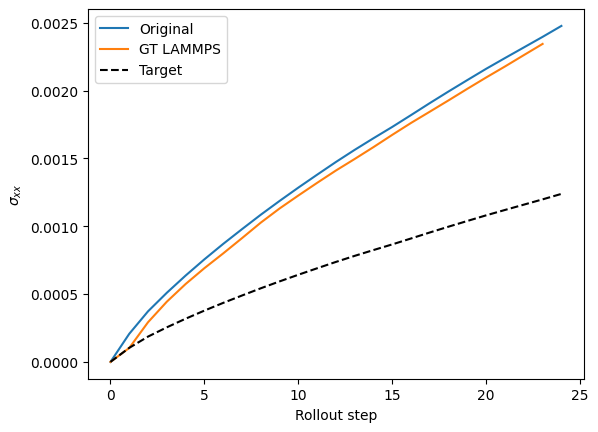

Epoch:   0 | pos: 6.224e-07 | slope: 2.912e-09 | curve: 3.098e-11 | 2.55 s.


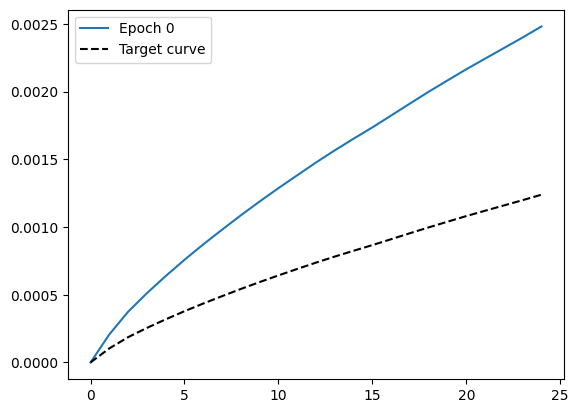

Epoch:   1 | pos: 5.879e-07 | slope: 2.743e-09 | curve: 2.862e-11 | 5.56 s.
Epoch:   2 | pos: 5.535e-07 | slope: 2.589e-09 | curve: 2.700e-11 | 5.98 s.
Epoch:   3 | pos: 5.212e-07 | slope: 2.462e-09 | curve: 3.119e-11 | 6.27 s.
Epoch:   4 | pos: 4.779e-07 | slope: 2.260e-09 | curve: 2.791e-11 | 8.03 s.
Epoch:   5 | pos: 4.434e-07 | slope: 2.094e-09 | curve: 2.791e-11 | 9.24 s.


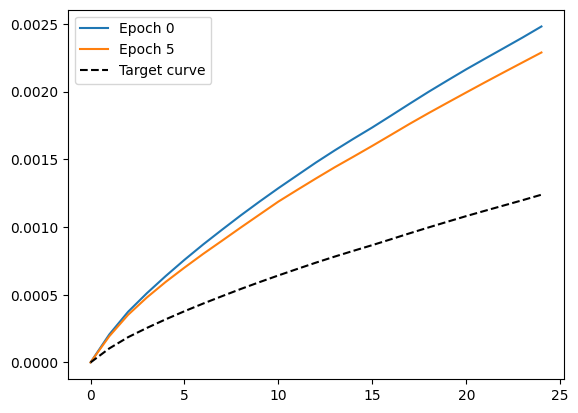

Epoch:   6 | pos: 3.949e-07 | slope: 1.874e-09 | curve: 2.518e-11 | 9.63 s.
Epoch:   7 | pos: 3.729e-07 | slope: 1.778e-09 | curve: 2.379e-11 | 8.21 s.
Epoch:   8 | pos: 3.326e-07 | slope: 1.585e-09 | curve: 2.354e-11 | 8.68 s.
Epoch:   9 | pos: 3.051e-07 | slope: 1.453e-09 | curve: 2.133e-11 | 5.92 s.
Epoch:  10 | pos: 2.880e-07 | slope: 1.371e-09 | curve: 1.952e-11 | 6.64 s.


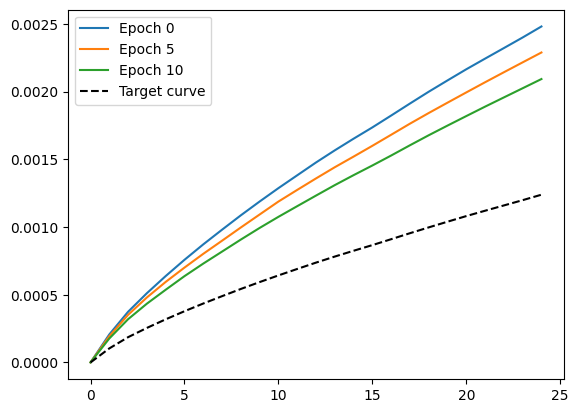

Epoch:  11 | pos: 2.347e-07 | slope: 1.126e-09 | curve: 1.865e-11 | 6.41 s.
Epoch:  12 | pos: 1.854e-07 | slope: 8.986e-10 | curve: 1.925e-11 | 6.61 s.
Epoch:  13 | pos: 1.539e-07 | slope: 7.551e-10 | curve: 1.800e-11 | 7.75 s.
Epoch:  14 | pos: 1.306e-07 | slope: 6.343e-10 | curve: 1.735e-11 | 13.19 s.
Epoch:  15 | pos: 8.116e-08 | slope: 4.195e-10 | curve: 1.846e-11 | 13.04 s.


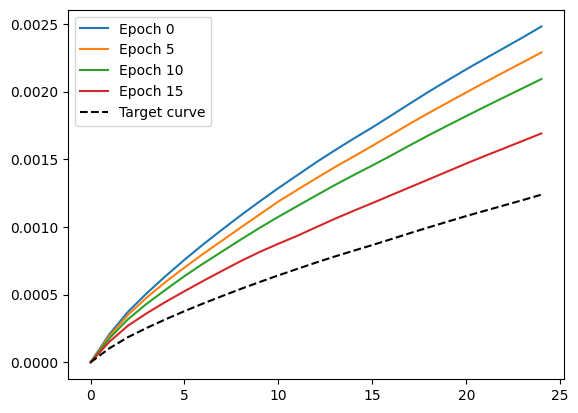

Epoch:  16 | pos: 4.967e-08 | slope: 2.623e-10 | curve: 1.128e-11 | 13.25 s.
Epoch:  17 | pos: 1.483e-07 | slope: 1.456e-08 | curve: 1.198e-08 | 13.39 s.
Epoch:  18 | pos: 4.292e-08 | slope: 2.367e-10 | curve: 2.323e-11 | 13.38 s.
Epoch:  19 | pos: 5.169e-08 | slope: 2.604e-10 | curve: 2.070e-11 | 13.90 s.
Epoch:  20 | pos: 3.929e-08 | slope: 2.206e-10 | curve: 1.727e-11 | 14.13 s.


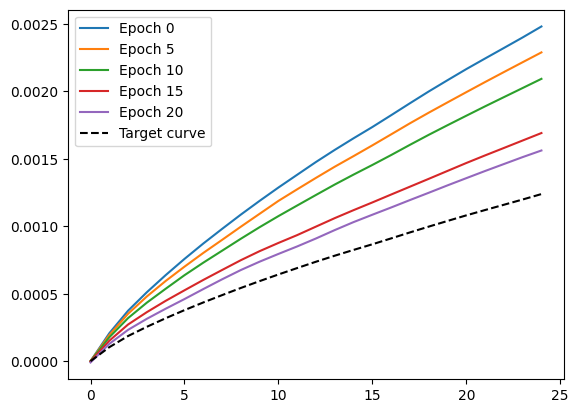

Epoch:  21 | pos: 3.357e-08 | slope: 1.923e-10 | curve: 2.367e-11 | 14.12 s.
Epoch:  22 | pos: 2.517e-08 | slope: 1.458e-10 | curve: 2.160e-11 | 14.21 s.
Epoch:  23 | pos: 3.367e-08 | slope: 3.139e-10 | curve: 1.192e-10 | 14.11 s.
Epoch:  24 | pos: 5.263e-08 | slope: 1.243e-09 | curve: 7.205e-10 | 14.38 s.
Epoch:  25 | pos: 3.402e-08 | slope: 1.698e-10 | curve: 2.024e-11 | 14.46 s.


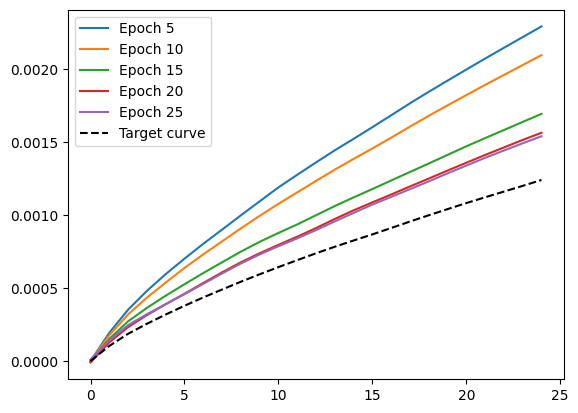

Epoch:  26 | pos: 4.551e-08 | slope: 2.436e-10 | curve: 1.313e-11 | 14.56 s.
Epoch:  27 | pos: 4.531e-08 | slope: 2.464e-10 | curve: 1.747e-11 | 14.10 s.
Epoch:  28 | pos: 3.691e-08 | slope: 2.097e-10 | curve: 1.959e-11 | 14.08 s.
Epoch:  29 | pos: 4.744e-08 | slope: 2.385e-10 | curve: 2.041e-11 | 14.02 s.
Epoch:  30 | pos: 3.837e-08 | slope: 2.043e-10 | curve: 2.267e-11 | 14.13 s.


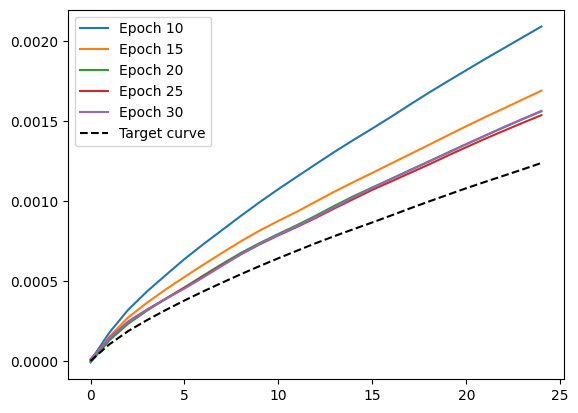

Epoch:  31 | pos: 2.839e-08 | slope: 1.567e-10 | curve: 1.785e-11 | 13.86 s.
Epoch:  32 | pos: 4.324e-08 | slope: 1.429e-09 | curve: 8.497e-10 | 16.99 s.
Epoch:  33 | pos: 4.458e-08 | slope: 2.449e-10 | curve: 1.826e-11 | 14.14 s.
Epoch:  34 | pos: 3.589e-08 | slope: 1.882e-10 | curve: 1.461e-11 | 14.33 s.
Epoch:  35 | pos: 4.061e-08 | slope: 2.206e-10 | curve: 2.183e-11 | 14.21 s.


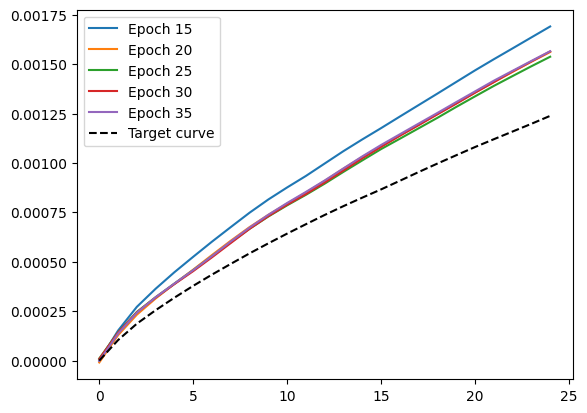

Epoch:  36 | pos: 3.377e-08 | slope: 1.778e-10 | curve: 1.671e-11 | 14.37 s.
Epoch:  37 | pos: 4.287e-08 | slope: 2.060e-10 | curve: 9.593e-12 | 14.28 s.
Epoch:  38 | pos: 5.544e-08 | slope: 3.156e-10 | curve: 3.223e-11 | 14.21 s.
Epoch:  39 | pos: 6.416e-08 | slope: 3.739e-10 | curve: 3.774e-11 | 14.06 s.
Epoch:  40 | pos: 5.363e-08 | slope: 2.885e-10 | curve: 1.773e-11 | 14.10 s.


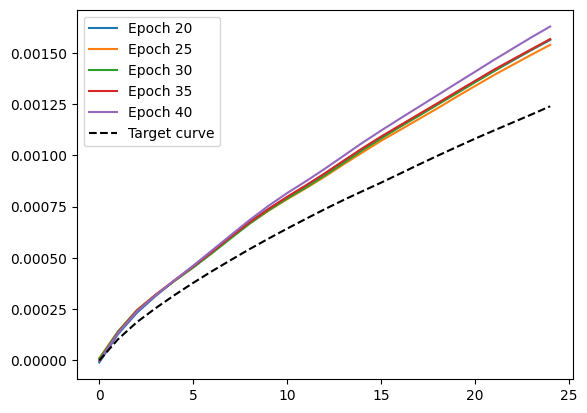

Epoch:  41 | pos: 6.078e-08 | slope: 3.211e-10 | curve: 1.596e-11 | 13.93 s.
Epoch:  42 | pos: 4.805e-08 | slope: 2.749e-10 | curve: 2.406e-11 | 14.02 s.
Epoch:  43 | pos: 5.715e-08 | slope: 3.049e-10 | curve: 1.945e-11 | 14.01 s.
Epoch:  44 | pos: 5.639e-08 | slope: 3.018e-10 | curve: 1.768e-11 | 14.15 s.
Epoch:  45 | pos: 4.997e-08 | slope: 2.651e-10 | curve: 1.259e-11 | 14.04 s.


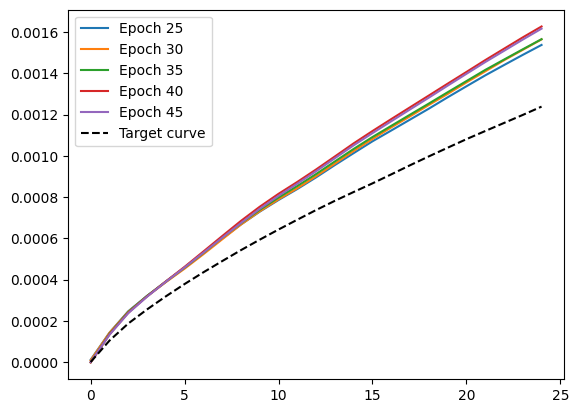

Epoch:  46 | pos: 3.279e-08 | slope: 1.872e-10 | curve: 1.905e-11 | 14.02 s.
Epoch:  47 | pos: 3.153e-08 | slope: 1.799e-10 | curve: 1.844e-11 | 15.48 s.
Epoch:  48 | pos: 2.566e-08 | slope: 1.564e-10 | curve: 3.229e-11 | 14.13 s.
Epoch:  49 | pos: 1.367e-08 | slope: 4.317e-10 | curve: 4.221e-10 | 14.01 s.


In [22]:
prepared_sim = data["train"][0]

torch.save(prepared_sim, os.path.join(OPT_RESULTS_DIR, "original_gt_sim.pt"))

# prepared_sim = torch.load("/home/sergey/work/gnn/GNNInverseDesign/check/optimized/optimized_to_half.pt", weights_only=False)
graph = prepared_sim[0].cpu().detach().clone()

gnn_simulator = models['h3 mst epoch 87']
gnn_history = 3

barostat_config = barostat_parameters.lj_noisy
lj_params = LJInteractionParams(0.01, 1.0, 1.122)
rollout_steps = 20
sample_stride = 1
md_steps = (gnn_history * barostat_config['default_skip'])+1

with torch.no_grad():
    baseline_traj = simulate_then_rollout(
        starting_graph=graph,
        gnn_simulator=gnn_simulator,
        gnn_history=gnn_history,
        barostat_config=barostat_config,
        lj_params=lj_params,
        md_steps=md_steps,
        rollout_steps=rollout_steps,
        device=device
    )

    # Compute the initial stress curve
    baseline_curve = compute_stress_curve(baseline_traj, lj_cutoff=lj_params.cutoff, sample_stride=sample_stride, device=device)
    gt_curve = compute_stress_curve(prepared_sim[:rollout_steps+history+1], lj_cutoff=lj_params.cutoff, sample_stride=sample_stride, device=device)
    steps = [v*sample_stride for v in range(len(baseline_curve))]

stress_xx = baseline_curve[:, 0]
stress_xx_gt = gt_curve[:, 0]
target_stress_curve = stress_xx * 0.5

plt.plot(stress_xx.cpu().detach(), label='Original')
plt.plot(stress_xx_gt.cpu().detach(), label='GT LAMMPS')
plt.plot(target_stress_curve.cpu().detach(), linestyle='--', color='black', label='Target')
plt.ylabel(r"$\sigma_{xx}$")
plt.xlabel(r"Rollout step")
plt.legend()
plt.show()

opt_graph, opt_traj, result = optimize_curve_stiffness(
    graph=graph,
    baseline_curve=baseline_curve,
    target_stress_curve=target_stress_curve,
    gnn_simulator=gnn_simulator,
    gnn_history=gnn_history,
    barostat_config=barostat_config,
    lj_params=lj_params,
    itpo_weights=None,
    rollout_steps=rollout_steps,
    epochs=50,
    draw_every=5,
    lr=0.05,
    alpha=1.0,
    beta=1.0,
    device=device
)

In [32]:
optimization_results = (opt_graph, opt_traj, result)

torch.save(optimization_results, os.path.join(OPT_RESULTS_DIR, "optimization_results_gnn_stiffness.pt"))

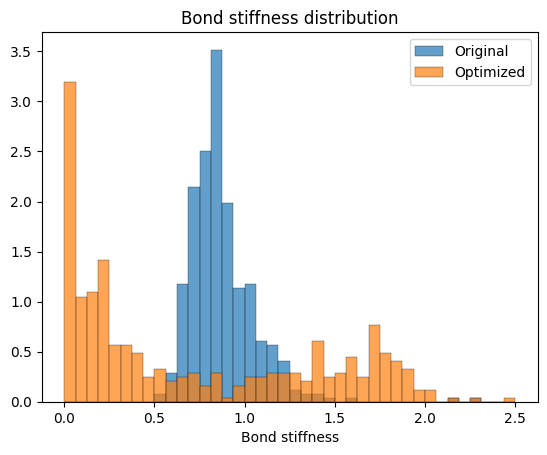

In [47]:
data_optimized = opt_graph.edge_attr.cpu().detach()
is_harmonic = data_optimized[:, 0].bool()
optimized_stiffness = data_optimized[is_harmonic, 5]

data_original = graph.edge_attr.cpu().detach()
is_harmonic = data_original[:, 0].bool()
original_stiffness = data_original[is_harmonic, 5]

data_min = min(optimized_stiffness.min(), original_stiffness.min())
data_max = max(optimized_stiffness.max(), original_stiffness.max())
shared_bins = np.linspace(data_min, data_max, 41)

plt.title('Bond stiffness distribution')
plt.hist(original_stiffness,  bins=shared_bins, alpha=0.7, density=True, edgecolor='black', linewidth=0.3, label='Original')
plt.hist(optimized_stiffness, bins=shared_bins, alpha=0.7, density=True, edgecolor='black', linewidth=0.3, label='Optimized')
plt.xlabel('Bond stiffness')
plt.legend()
plt.show()

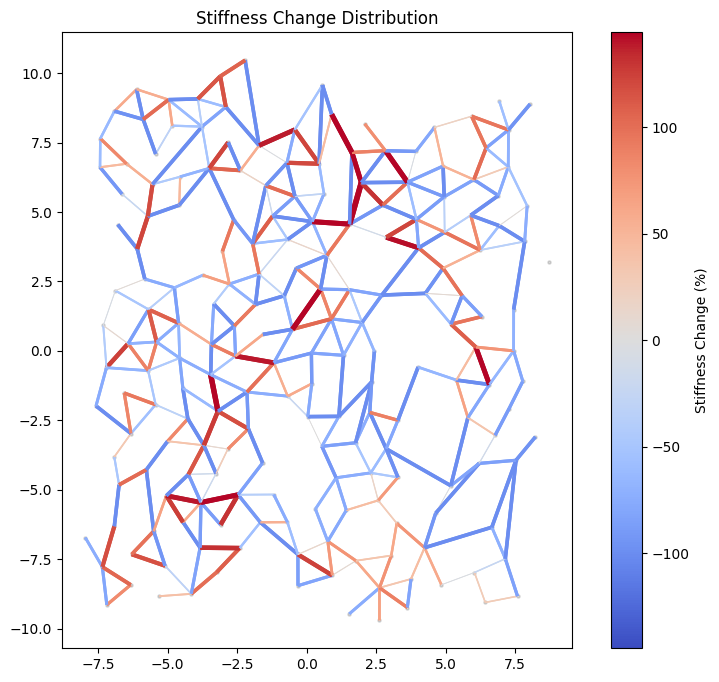

In [48]:
def visualize_stiffness_change_target(
    graph: Data,
    initial_stiff: Tensor,
    new_stiff: Tensor,
    box_tensor: Tensor | None = None,
    title="Stiffness Change Distribution",
    target_node: int | None = None,
    defect_radius: float | None = None,
    target_color: str = "red",       
    neighbor_color: str = "orange"
):
    # 1. Prepare Data
    pos = graph.x.detach().cpu().numpy()
    edge_attr = graph.edge_attr.cpu().detach()
    is_harmonic = edge_attr[:, 0].bool()
    edge_index = graph.edge_index.detach().cpu().numpy()
    edge_index = edge_index.T[is_harmonic].T
    
    k_init = initial_stiff.detach().cpu().numpy()
    k_new = new_stiff.detach().cpu().numpy()
    
    # Calculate % change
    delta = (k_new - k_init) / (k_init + 1e-9) * 100 

    # 2. Create Segments
    start_pos = pos[edge_index[0]]
    end_pos = pos[edge_index[1]]
    
    # --- Periodic Edge Filter ---
    mask = np.ones(len(edge_index[0]), dtype=bool)
    if box_tensor is not None:
        box = box_tensor.detach().cpu().numpy()
        # Calculate visual distance (dx, dy)
        diff = np.abs(start_pos - end_pos)
        # If dx > box_x/2 or dy > box_y/2, it wraps. Hide it.
        wrap_check = (diff[:, 0] > box[0] / 2.0) | (diff[:, 1] > box[1] / 2.0)
        mask = ~wrap_check # Keep only non-wrapping edges

    # Apply mask to data
    start_pos = start_pos[mask]
    end_pos = end_pos[mask]
    delta = delta[mask]
    
    segments = np.stack((start_pos, end_pos), axis=1)

    # 3. Setup Plot
    _fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
    
    # Draw base nodes (pushed to background with zorder=1)
    ax.scatter(pos[:, 0], pos[:, 1], c='gray', s=5, alpha=0.3, zorder=1)

    # --- 3.5. Highlight Target and Neighbors ---
    if target_node is not None and defect_radius is not None:
        target_pos = pos[target_node]
        
        # Calculate distances using NumPy
        dist_to_target = np.linalg.norm(pos - target_pos, axis=1)
        
        # Isolate neighbors (excluding the target itself)
        neighbor_mask = (dist_to_target <= defect_radius) & (dist_to_target > 0)
        neighbor_pos = pos[neighbor_mask]
        
        # Plot neighbors with slightly larger size
        if len(neighbor_pos) > 0:
            ax.scatter(neighbor_pos[:, 0], neighbor_pos[:, 1], 
                       c=neighbor_color, s=20, alpha=0.9, zorder=3)
        
        # Plot target node prominently
        ax.scatter(target_pos[0], target_pos[1], 
                   c=target_color, s=40, edgecolors='black', zorder=4)
        
        # Draw the radius circle
        circle = patches.Circle(
            (target_pos[0], target_pos[1]), 
            radius=defect_radius, 
            fill=False, 
            color=target_color, 
            linestyle='--', 
            linewidth=1.5,
            alpha=0.8,
            zorder=2
        )
        ax.add_patch(circle)

    # 4. Color Mapping
    # Avoid zero-length array issues if all deltas are exactly 0
    if len(delta) > 0 and np.max(np.abs(delta)) > 0:
        limit = np.percentile(np.abs(delta), 98) # Smart auto-scale
        if limit == 0:
            limit = 1e-5 # Prevent norm errors
    else:
        limit = 1.0

    norm = mcolors.TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)
    cmap = plt.cm.coolwarm 

    lc = LineCollection(segments, cmap=cmap, norm=norm, zorder=2)
    lc.set_array(delta)
    
    # Variable thickness based on magnitude of change
    linewidths = 0.5 + 3.0 * (np.abs(delta) / limit)
    lc.set_linewidth(np.clip(linewidths, 0.5, 4.0)) # Clip max width
    
    ax.add_collection(lc)
    
    cbar = plt.colorbar(lc, ax=ax)
    cbar.set_label('Stiffness Change (%)')
    ax.set_title(title)
    ax.set_aspect('equal')
    
    plt.show()

visualize_stiffness_change_target(
    opt_graph,
    original_stiffness,
    optimized_stiffness,
    opt_graph.box_tensor,
    target_node=None,
    defect_radius=None)

In [52]:
# Run minimization again before lammps
with torch.no_grad():
    torch_simulator = DifferentiableCompression64(opt_graph.num_nodes, lj_params=lj_params)
    min_opt_graph = torch_simulator.minimize(to_f64(opt_graph.cpu().detach()), max_iter=30_000, r0=opt_graph.edge_attr[:, 6], box_lr=0.1)

    stress_original, _ = compute_stress_pressure(graph.x, graph.edge_index, graph.edge_attr, graph.box_tensor, lj_params.cutoff, None)
    stress_before, _ = compute_stress_pressure(opt_graph.x, opt_graph.edge_index, opt_graph.edge_attr, opt_graph.box_tensor, lj_params.cutoff, None)
    stress_after, _  = compute_stress_pressure(min_opt_graph.x, min_opt_graph.edge_index, min_opt_graph.edge_attr, min_opt_graph.box_tensor, lj_params.cutoff, None)

    print(f"Stress original:\n {stress_original}\n")
    print(f"Stress before:\n {stress_before}\n")
    print(f"Stress after:\n {stress_after}")

Stress original:
 tensor([-4.2585e-07,  3.9008e-07, -5.7197e-03])

Stress before:
 tensor([-1.7563e-04,  8.1719e-05, -1.4065e-04], dtype=torch.float64)

Stress after:
 tensor([-1.5444e-06, -3.2788e-06,  5.7156e-05], dtype=torch.float64)


In [53]:
check_dir = "/home/sergey/work/gnn/GNNInverseDesign/check"
if not os.path.exists(check_dir):
    os.makedirs(check_dir, exist_ok=True)

opt_path = os.path.join(check_dir, 'optimized')
os.makedirs(opt_path, exist_ok=True)
orig_path = os.path.join(check_dir, 'original')
os.makedirs(orig_path, exist_ok=True)

optimized_network = network.Network.from_data_file(os.path.join(opt_path, "network.lmp"))
optimized_rest_lengths = torch.tensor([b.length for b in optimized_network.bonds])
optimized = check_graph_with_lammps(
    graph=min_opt_graph,
    lj_params=lj_params,
    lammps_calc_dir=opt_path,
    strain=0.001
)
original_network = network.Network.from_data_file(os.path.join(orig_path, "network.lmp"))
original_rest_lengths = torch.tensor([b.length for b in original_network.bonds])
original = check_graph_with_lammps(
    graph=graph,
    lj_params=lj_params,
    lammps_calc_dir=orig_path,
    strain=0.001
)

optimized = prepare_traj(optimized, lj_params, optimized_rest_lengths, True)
original = prepare_traj(original, lj_params, original_rest_lengths, True)

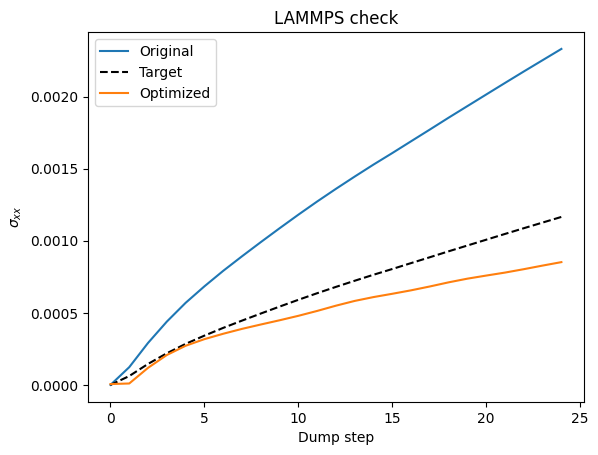

In [54]:
original_stress = compute_stress_curve(original, lj_cutoff=lj_params.cutoff, sample_stride=1, device=device)
target_stress = original_stress * 0.5 
optimized_stress = compute_stress_curve(optimized, lj_cutoff=lj_params.cutoff, sample_stride=1, device=device)    

plt.plot(original_stress[:25, 0].cpu().detach(), label='Original')
plt.plot(target_stress[:25, 0].cpu().detach(), linestyle="--", color="black", label='Target')
plt.plot(optimized_stress[:25, 0].cpu().detach(), label='Optimized')
plt.ylabel(r"$\sigma_{xx}$")
plt.xlabel(r"Dump step")
plt.title("LAMMPS check")
plt.legend()
plt.show()

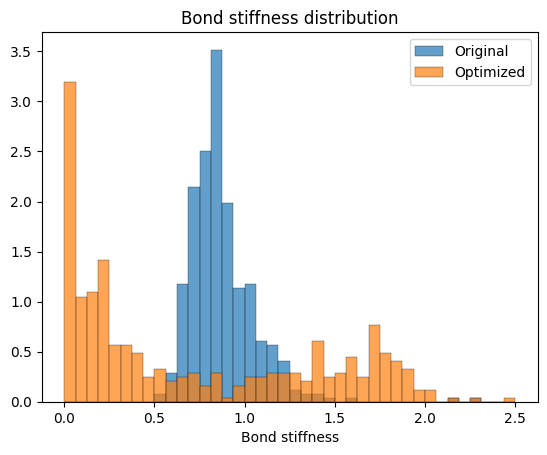

In [55]:
data_optimized = optimized[0].edge_attr.cpu().detach()
is_harmonic = data_optimized[:, 0].bool()
optimized_stiffness = data_optimized[is_harmonic, 5]

data_original = graph.edge_attr.cpu().detach()
is_harmonic = data_original[:, 0].bool()
original_stiffness = data_original[is_harmonic, 5]

data_min = min(optimized_stiffness.min(), original_stiffness.min())
data_max = max(optimized_stiffness.max(), original_stiffness.max())
shared_bins = np.linspace(data_min, data_max, 41)

plt.title('Bond stiffness distribution')
plt.hist(original_stiffness,  bins=shared_bins, alpha=0.7, density=True, edgecolor='black', linewidth=0.3, label='Original')
plt.hist(optimized_stiffness, bins=shared_bins, alpha=0.7, density=True, edgecolor='black', linewidth=0.3, label='Optimized')
plt.xlabel('Bond stiffness')
plt.legend()
plt.show()

#### Compress each graph from saved with lammps

In [69]:
opt_graph, opt_traj, results = torch.load("/home/sergey/work/gnn/GNNInverseDesign/stress_curve_optimization/optimization_results_gnn_stiffness.pt", weights_only=False)

check_dir = "/home/sergey/work/gnn/GNNInverseDesign/check"
if not os.path.exists(check_dir):
    os.makedirs(check_dir, exist_ok=True)

opt_path = os.path.join(check_dir, 'optimized')
os.makedirs(opt_path, exist_ok=True)

optimized_network = network.Network.from_data_file(os.path.join(opt_path, "network.lmp"))
optimized_rest_lengths = torch.tensor([b.length for b in optimized_network.bonds])

with torch.no_grad():
    torch_simulator = DifferentiableCompression64(opt_graph.num_nodes, lj_params=lj_params)

    trajectories = []
    stresses = []
    # for epoch, epoch_graph in enumerate(results['graphs']):
    for epoch, curve in enumerate(results['curves']):
        if epoch % 5 == 0:
            # minimize graph
            # minimized_graph = torch_simulator.minimize(to_f64(epoch_graph.cpu().detach()), max_iter=30_000, r0=epoch_graph.edge_attr[:, 6], box_lr=0.03)

            # compress with lammps
            # lammps_traj = check_graph_with_lammps(
            #     graph=minimized_graph,
            #     lj_params=lj_params,
            #     lammps_calc_dir=opt_path,
            #     strain=0.001
            # )
            # lammps_traj = prepare_traj(lammps_traj, lj_params, optimized_rest_lengths)
            # trajectories.append(lammps_traj)

            # Compute stress
            # epoch_curve = compute_stress_curve(lammps_traj, lj_cutoff=lj_params.cutoff, sample_stride=1, device=device)
            stresses.append(curve.detach().cpu())

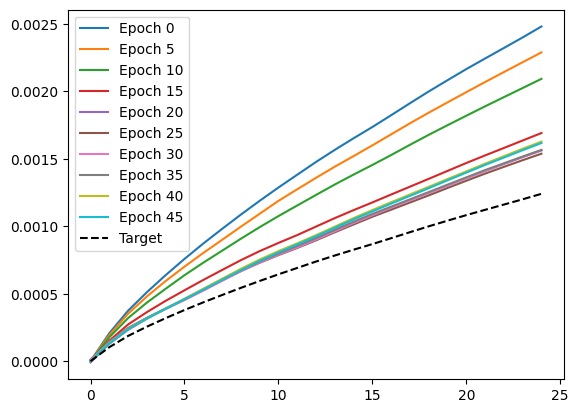

In [73]:
for epoch, curve in enumerate(stresses):
    plt.plot(curve[:, 0], label=f"Epoch {epoch * 5}")

plt.plot(stresses[0][:, 0] * 0.5, linestyle='--', color='black', label='Target')
plt.legend()
plt.show()

### Optimizing stress-strain with torch-simulator

#### Functions

In [ ]:
def get_reverse_edge_indices(edge_index: Tensor) -> Tensor:
    """
    Returns a tensor 'rev_idx' such that edge_index[:, i] is the reverse of edge_index[:, rev_idx[i]].
    Assumes every edge has a reverse.
    """
    # Convert (u, v) to a single unique number to find matches easily
    # We assume node indices fit in 32/64 bit integers.
    # Max node index * multiplier + min node index approach.

    src, dst = edge_index

    # 1. Create a hash/id for every edge
    # This ID is unique for every directed edge
    # Using complex numbers is a quick hack to keep pairs together: u + iv
    # But simple Cantor pairing or large integer multiplication is safer for tensors
    scaling = src.max() + 1
    edge_ids = src * scaling + dst
    reverse_edge_ids = dst * scaling + src

    # 2. Find where the reverse ID exists in the original list
    # Torch's sort is efficient for this
    perm = torch.argsort(edge_ids)
    sorted_ids = edge_ids[perm]

    # Find indices of reverse edges in the sorted array
    sorted_rev_indices = torch.searchsorted(sorted_ids, reverse_edge_ids)

    # Map back to original indices
    rev_idx = perm[sorted_rev_indices]

    return rev_idx


def shape_aware_loss(pred_curve: Tensor, target_curve: Tensor):
    # 1. Positional Loss (Standard MSE)
    # Ensures the curves are generally in the same place
    loss_pos = torch.nn.functional.mse_loss(pred_curve, target_curve)
    
    # 2. Slope Loss (First Derivative)
    # Forces the optimized curve to go in the same direction
    pred_d1 = torch.diff(pred_curve)
    target_d1 = torch.diff(target_curve)
    loss_slope = torch.nn.functional.mse_loss(pred_d1, target_d1)
    
    # 3. Curvature Loss (Second Derivative)
    # Forces the optimized curve to physically bend like the target
    pred_d2 = torch.diff(pred_d1)
    target_d2 = torch.diff(target_d1)
    loss_curve = torch.nn.functional.mse_loss(pred_d2, target_d2)
    
    # Combine them. You may need to tune alpha and beta depending on the scale of your values.
    # Usually, a heavily weighted second derivative forces the bend beautifully.
    # total_loss = loss_pos + (alpha * loss_slope) + (beta * loss_curve)
    
    return loss_pos, loss_slope, loss_curve


def optimize_torch_curve_stiffness(
    graph: Data,
    target_stress_curve: Tensor,
    lj_params: LJInteractionParams,
    md_steps: int,
    sample_stride: int,
    epochs: int,
    draw_every: int,
    lr: float,
    alpha: float = 1.0,
    beta: float = 1.0,
    device: str = "cpu",
) -> Data:

    # Store curves
    curves = []

    # Prepare graph
    graph.x = graph.x.double()
    graph.edge_attr = graph.edge_attr.double()
    graph.box_tensor = graph.box_tensor.double()

    # Prepare
    is_harmonic = graph.edge_attr[:, 0].bool()
    stiff_idx = 5
    r0_idx = 6

    # Extract initial stiff
    initial_stiff = graph.edge_attr[is_harmonic, stiff_idx].clone()
    
    # We only want reverse indices within the harmonic edge subset
    harm_edge_index = graph.edge_index[:, is_harmonic]
    rev_idx = get_reverse_edge_indices(harm_edge_index).to(device)

    # Setup optimization (parameter size matches harmonic edges)
    stiffness_adjustment = torch.nn.Parameter(torch.zeros_like(initial_stiff, requires_grad=True, device=device))
    optimizer = torch.optim.AdamW([stiffness_adjustment], lr=lr)
    lr_scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, 0.995, last_epoch=-1)

    # Precalculate the log scales
    max_mult = 1e2
    min_mult = 1e-2
    log_max = torch.log(torch.tensor(max_mult, device=device))   
    log_min = torch.log(torch.tensor(min_mult, device=device))

    # Init torch simulator
    simulator = DifferentiableCompression64(
        num_particles=graph.num_nodes, lj_params=lj_params, factor_two=True,
    )

    for epoch in range(epochs):
        t_start = time.time()
        optimizer.zero_grad()

        # Create a fresh copy of the graph every
        curr_graph = graph.clone()
        # Explicit clone of edge_attr so we don't accidentally mutate the base graph in place
        curr_graph.edge_attr = curr_graph.edge_attr.clone()

        # Add stiffness change symmetrically      
        symmetric_adjustment = (stiffness_adjustment + stiffness_adjustment[rev_idx]) / 2.0
        
        scale = torch.where(symmetric_adjustment >= 0, log_max, -log_min)

        # Exp + Tanh guarantees smooth bounds and exact 1.0 resting state
        multiplier = torch.exp(scale * torch.tanh(symmetric_adjustment))
        new_stiff = initial_stiff * multiplier

        # Safely inject the new stiffness into the harmonic bonds
        curr_graph.edge_attr[is_harmonic, stiff_idx] = new_stiff
        
        # Update r0
        # curr_graph.edge_attr[is_harmonic, r0_idx] = new_r0

        # Minimize configuration
        current_harmonic_r0 = curr_graph.edge_attr[is_harmonic, r0_idx]
        curr_graph = simulator.minimize(
            graph=curr_graph,
            r0=current_harmonic_r0,
            max_iter=1000,
        )

        # 4. Check new P
        curr_traj, cond = simulator.run_simulator(
            initial_data=curr_graph, steps=md_steps, r0=curr_graph.edge_attr[:, 6],
            debug=False, device=device
        )
        
        # 5. Calculate Poisson's ratio
        curr_stress_curve = compute_stress_curve(curr_traj, lj_cutoff=lj_params.cutoff, sample_stride=1, device=device)
        curr_stress_xx_curve = curr_stress_curve[:, 0]
        curr_stress_xx_curve = curr_stress_xx_curve[::sample_stride]

        # 6. Calculate Poisson ratio loss
        loss_pos, loss_slope, loss_curve = shape_aware_loss(curr_stress_xx_curve, target_stress_curve)

        # 8. Compute total loss
        loss = loss_pos + alpha*loss_slope + beta*loss_curve

        # try:
        #     grad_check = torch.autograd.grad(angle_loss, displacement, retain_graph=True)
        #     print(f"Mean grad: {grad_check[0].abs().mean().item()}")
        # except RuntimeError as e:
        #     print(f"error: {e}")

        loss.backward()

        # if stiffness_adjustment.grad is not None:
        #     grad_mean = stiffness_adjustment.grad.abs().mean().item()
        #     grad_max = stiffness_adjustment.grad.abs().max().item()
        #     print(f"   Gradient Mean: {grad_mean:.4e} | Max: {grad_max:.4e}")
        #     if grad_mean < 1e-9:
        #         print("GRADIENT VANISHED.")
        # else:
        #     print("NO GRADIENT on displacement variable.")

        torch.nn.utils.clip_grad_norm_(stiffness_adjustment, max_norm=1.0)

        optimizer.step()
        lr_scheduler.step()
        
        t_end = time.time()

        print(f"Epoch: {epoch:>3} | "
              f"pos: {loss_pos.item():.3e} | "
              f"slope: {alpha*loss_slope.item():.3e} | "
              f"curve: {beta*loss_curve.item():.3e} | "
              f"{t_end - t_start:.2f} s.")

        if epoch % draw_every == 0:
            curves.append(curr_stress_xx_curve.clone().cpu().detach())
            curves_to_plot = [(i, curve) for i, curve in enumerate(curves) if len(curves) - i <= 5]
            for i, curve in curves_to_plot:
                plt.plot(curve, label=f'Epoch {i * draw_every}')
            
            plt.plot(target_stress_curve.clone().cpu().detach(), label='Target curve', color='gray', linestyle='dashed')
            plt.legend()
            plt.show()

    return curr_graph, curr_traj


def to_directed(graph: Data) -> tuple[Tensor, Tensor]:
    """
    Converts a bidirected graph to a directed one.
    Assumes the input graph is bidirected.
    """
    src, dst = graph.edge_index
    
    # Create a boolean mask keeping only one direction
    mask = src < dst 
    
    directed_edge_index = graph.edge_index[:, mask]
    
    if hasattr(graph, 'edge_attr') and graph.edge_attr is not None:
        directed_edge_attr = graph.edge_attr[mask]
    else:
        directed_edge_attr = None
        
    return directed_edge_index, directed_edge_attr


def to_old_format(graph: Data) -> tuple[Tensor, Tensor]:
    """
    Converts a graph to old edge format [vec_x, vec_y, length, stiffness]. 
    Removes LJ edge attr.
    Assumes the input graph is new format (7D).
    """
    num_features = graph.edge_attr.shape[1]
    if num_features != 7:
        raise ValueError(f"Input graph has {num_features} edge features, should be 7.")
    
    # Create the boolean mask
    is_harmonic = graph.edge_attr[:, 0].bool()
    
    # Slice edge_index
    harmonic_bond_index = graph.edge_index[:, is_harmonic]
    
    # Slice edge_attr
    old_format_edge_attr = graph.edge_attr[is_harmonic, 2:6] # 2 vx 3 vy 4 dist 5 stiff
        
    return harmonic_bond_index, old_format_edge_attr


def to_network(graph: Data) -> network.Network:
    """Converts torch_geometric `Data` object into `Network` object from network.py.

    Parameters
    ----------
    graph : Data
        input graph

    Returns
    -------
    network.Network
        An object that represents an elastic network
    """
    # create atoms
    atoms = []
    for index, node in enumerate(graph.x):
        atom_id = index + 1
        x = float(node[0])
        y = float(node[1])
        atoms.append(network.Atom(atom_id=atom_id, atom_diameter=0.0, x=x, y=y, z=0.0))

    # update bonds
    bonds = []
    for index, ((source_id, target_id), (ux, uy, length, k)) in enumerate(zip(graph.edge_index.T, graph.edge_attr)):
        atom1 = atoms[int(source_id)]
        atom1.n_bonds += 1
        atom2 = atoms[int(target_id)]
        atom2.n_bonds += 1
        atom2.bonded.append(atom1.atom_id)
        atom1.bonded.append(atom2.atom_id)
        bond_coefficient = float(k.detach().cpu())
        length = float(length.cpu().detach())

        bond = network.Bond(atom1, atom2)
        bond.bond_coefficient = bond_coefficient
        bond.length = length

        bonds.append(bond)

    box_x, box_y = graph.box_tensor[0].item(), graph.box_tensor[1].item()
    box = network.Box(x1=-box_x / 2, x2=box_x / 2, y1=box_y / 2, y2=-box_y / 2, z1=-0.1, z2=0.1)

    header = network.Header(
        atoms,
        bonds,
        box,
    )

    return network.Network(atoms, bonds, box, header, masses={1: 1_000_000.0})


def run_lammps_calc(calculation_directory: str, input_file: str = "lammps.in"):
    """
    A helper function which runs the external lammps code.
    """
    input_file_path = os.path.join(calculation_directory, input_file)
    command = f"lmp -in {input_file_path}".split()

    os.chdir(calculation_directory)
    os.environ["OMP_NUM_THREADS"] = str(1)
    subprocess.run(command, stdout=subprocess.DEVNULL)


def assemble_data(
    atoms: list[network.Atom],
    bonds: list[network.Bond],
    box: network.Box,
    node_features: str = "coord",
) -> Data:
    """Optimized helper function which assembles the PyTorch_Geometric `Data` object.
    
    Parameters
    ----------
    `atoms` : list
        list of `network.Atom` objects transformed into nodes
    `bonds` : list
        list of `network.Bond` objects transformed into edges
    `node_features` : str, optional
        which node features to include, by default "coord"
    
    Returns
    -------
    Data
        PyTorch_Geometric `Data` object
    """
    n_atoms = len(atoms)
    n_bonds = len(bonds)
    
    # Vectorized atom ID extraction and mapping
    atom_ids_np = np.array([atom.atom_id for atom in atoms], dtype=np.int64)
    atom_ids = torch.from_numpy(atom_ids_np)
    
    # Create efficient lookup using numpy
    max_id = atom_ids_np.max() + 1
    id_to_index = np.full(max_id, -1, dtype=np.int64)
    id_to_index[atom_ids_np] = np.arange(n_atoms)
    
    # Vectorized edge extraction
    edges_np = np.array([(bond.atom1.atom_id, bond.atom2.atom_id) for bond in bonds], dtype=np.int64)
    edges_with_indices = np.column_stack([
        id_to_index[edges_np[:, 0]],
        id_to_index[edges_np[:, 1]]
    ])
    edge_index = torch.from_numpy(edges_with_indices.T)
    
    # Vectorized edge attributes - build numpy arrays first
    edge_vectors_np = np.array([
        [bond.atom1.x - bond.atom2.x, bond.atom1.y - bond.atom2.y] 
        for bond in bonds
    ], dtype=np.float32)
    
    edge_lengths_np = np.array([bond.length for bond in bonds], dtype=np.float32)
    edge_coeffs_np = np.array([bond.bond_coefficient for bond in bonds], dtype=np.float32)
    
    # Convert to tensors once
    edge_vectors = torch.from_numpy(edge_vectors_np)
    edge_lengths = torch.from_numpy(edge_lengths_np).unsqueeze(1)
    edge_coeffs = torch.from_numpy(edge_coeffs_np).unsqueeze(1)
    
    # Concatenate efficiently
    edge_attr = torch.cat([edge_vectors, edge_lengths, edge_coeffs], dim=1)
    
    # Vectorized node features
    match node_features:
        case "dummy":
            node_features_tensor = torch.zeros((n_atoms, 1), dtype=torch.float32)
        case "vel":
            try:
                node_features_np = np.array([[atom.vx, atom.vy] for atom in atoms], dtype=np.float32)
                node_features_tensor = torch.from_numpy(node_features_np)
            except AttributeError:
                raise Exception("Atoms don't have velocity info")
        case "force":
            try:
                node_features_np = np.array([[atom.fx, atom.fy] for atom in atoms], dtype=np.float32)
                node_features_tensor = torch.from_numpy(node_features_np)
            except AttributeError:
                raise Exception("Atoms don't have forces info")
        case "coord":
            node_features_np = np.array([[atom.x, atom.y] for atom in atoms], dtype=np.float32)
            node_features_tensor = torch.from_numpy(node_features_np)
        case "full":
            node_features_np = np.array([
                [atom.x, atom.y, atom.vx, atom.vy, atom.fx, atom.fy] 
                for atom in atoms
            ], dtype=np.float32)
            node_features_tensor = torch.from_numpy(node_features_np)
        case _:
            raise Exception(f"{node_features} not recognized as feature!")
    
    # Create temporary Data object
    tmp = Data(
        x=node_features_tensor, 
        edge_index=edge_index, 
        edge_attr=edge_attr, 
        box=box, 
        atom_ids=atom_ids
    )
    
    # Get corrected edge vectors
    correct_edge_vectors = get_correct_edge_vec(tmp)
    
    # Update edge attributes efficiently
    updated_edge_attr = torch.cat([correct_edge_vectors, edge_lengths, edge_coeffs], dim=1)
    
    return Data(
        x=node_features_tensor,
        edge_index=edge_index,
        edge_attr=updated_edge_attr,
        box=box,
    )


def parse_dump(
    dump_filepath: str,
    original_network: network.Network,
    node_features: str = "coord",
    skip: int = 1,
) -> list[Data]:
    
    # Pre-compute lookups
    atom_diameter_map = {atom.atom_id: atom.diameter for atom in original_network.atoms}
    original_edge_index = np.array([
        (bond.atom1.atom_id, bond.atom2.atom_id) for bond in original_network.bonds
    ])

    # True equilibrium rest lengths (r0)
    bond_r0_map = {
        (bond.atom1.atom_id, bond.atom2.atom_id): bond.length
        for bond in original_network.bonds
    }

    bond_stiffness_map = {
        (bond.atom1.atom_id, bond.atom2.atom_id): bond.bond_coefficient
        for bond in original_network.bonds
    }


    # 1. Fast C-level split instead of line-by-line scanning
    with open(dump_filepath, "r", encoding="utf8") as f:
        raw_text = f.read()

    blocks = raw_text.split("ITEM: TIMESTEP\n")
    if not blocks[0].strip():
        blocks = blocks[1:]  # Remove the empty split before the first timestep

    data_list = []
    
    # Iterate with skip
    for i in range(0, len(blocks), skip):
        block = blocks[i]
        if not block.strip():
            continue
            
        lines = block.strip().split('\n')
        
        # Parse box info
        xlo, xhi, _ = map(float, lines[4].split())
        ylo, yhi, _ = map(float, lines[5].split())
        zlo, zhi, _ = map(float, lines[6].split())
        box = network.Box(xlo, xhi, ylo, yhi, zlo, zhi)
        box_x = xhi - xlo
        box_y = yhi - ylo

        # 2. Vectorized string-to-float parsing (much faster than split loops)
        atom_data = np.loadtxt(lines[8:])
        
        if atom_data.ndim == 1:
            atom_data = atom_data.reshape(1, -1)
            
        atom_ids = atom_data[:, 0].astype(int)
        positions = atom_data[:, 1:4]
        
        # 3. Check for velocities once to avoid try/except overhead in the loop
        has_velocities = atom_data.shape[1] >= 7
        if has_velocities:
            velocities = atom_data[:, 4:7]

        new_atoms = []
        atom_id_to_idx = {}
        
        # Local pointer optimization
        new_atoms_append = new_atoms.append
        
        for idx, atom_id in enumerate(atom_ids):
            atom = network.Atom(
                atom_id=atom_id,
                atom_diameter=atom_diameter_map[atom_id],
                x=positions[idx, 0],
                y=positions[idx, 1],
                z=positions[idx, 2],
            )
            if has_velocities:
                atom.vx = velocities[idx, 0]
                atom.vy = velocities[idx, 1]
                atom.vz = velocities[idx, 2]
                
            new_atoms_append(atom)
            atom_id_to_idx[atom_id] = idx

        # Get positions for all bonds
        idx1 = np.array([atom_id_to_idx[edge[0]] for edge in original_edge_index])
        idx2 = np.array([atom_id_to_idx[edge[1]] for edge in original_edge_index])
        
        pos1 = positions[idx1, :2] 
        pos2 = positions[idx2, :2]
        
        # 4. Faster PBC math using round (avoids boolean masking)
        delta = pos2 - pos1
        delta[:, 0] -= np.round(delta[:, 0] / box_x) * box_x
        delta[:, 1] -= np.round(delta[:, 1] / box_y) * box_y
        
        distances = np.linalg.norm(delta, axis=1)
        
        # Create bonds
        atom_map = {atom.atom_id: atom for atom in new_atoms}
        new_bonds = []
        new_bonds_append = new_bonds.append
        
        for bond_idx, (id1, id2) in enumerate(original_edge_index):
            new_bond = network.Bond(atom_map[id1], atom_map[id2])
            new_bond.length = distances[bond_idx]
            new_bond.bond_coefficient = bond_stiffness_map[(id1, id2)]
            new_bonds_append(new_bond)

        data_list.append(assemble_data(new_atoms, new_bonds, box, node_features=node_features))

    return data_list


def check_graph_with_lammps(
    graph: Data,
    lj_params: LJInteractionParams,
    lammps_calc_dir: str = "check",
    strain: float = 0.03,
    strain_rate: float = 1e-5,
    manual_dump_frequency: Optional[int] = 200
) -> List[Data]:
    
    # Convert to old format
    harmonic_edge_index, harmonic_edge_attr = to_old_format(graph)
    old_format_graph = Data(
        x=graph.x,
        edge_index=harmonic_edge_index,
        edge_attr=harmonic_edge_attr,
        box=graph.box if hasattr(graph, "box") else None,
        box_tensor=graph.box_tensor
    )

    # Convert to directed graph
    directed_edge_index, directed_edge_attr = to_directed(old_format_graph)
    directed_graph = Data(
        x=old_format_graph.x,
        edge_index=directed_edge_index,
        edge_attr=directed_edge_attr,
        box=old_format_graph.box if hasattr(old_format_graph, "box") else None,
        box_tensor=old_format_graph.box_tensor
    )

    # Convert to network object
    net = to_network(directed_graph)
    net.write_to_file(os.path.join(lammps_calc_dir, "network.lmp"))

    lj_params_dict = {
        'epsilon':        lj_params.epsilon,
        'sigma':          lj_params.sigma,
        'cutoff':         lj_params.cutoff,
        'exclude_bonded': False,
    }
    comp_sim = lammps_scripts.CompressionSimulation(
        box_size=net.box.x, strain=strain, strain_rate=strain_rate,
        temperature_range=lammps_scripts.TemperatureRange(1e-7, 1e-7, 10),
        overwrite_dump_freq=manual_dump_frequency,
        lj_active=True, lj_params=lj_params_dict
    )

    comp_sim.write_to_file(lammps_calc_dir)
    run_lammps_calc(lammps_calc_dir, input_file="in.deformation")

    lammps_traj = parse_dump(os.path.join(lammps_calc_dir, "dump.lammpstrj"), net, node_features="coord")
    return lammps_traj


In [ ]:
device = "cpu"
# prepared_sim = data["train"][0]
prepared_sim = torch.load("/home/sergey/work/gnn/GNNInverseDesign/check/optimized/optimized_to_half.pt", weights_only=False)
graph = prepared_sim[0].cpu().detach().clone()

lj_params = LJInteractionParams(0.01, 1.0, 1.122)
md_steps = 2_000
sample_stride = 200

# Init torch simulator
simulator = DifferentiableCompression64(
    num_particles=graph.num_nodes, lj_params=lj_params, factor_two=True,
)

with torch.no_grad():
    baseline_traj, _ = simulator.run_simulator(
        initial_data=graph.to(device),
        steps=md_steps,
        r0=graph.edge_attr[:, -2].to(device),
        debug=False,
        device=device
    )

    # Compute the initial stress curve
    baseline_curve = compute_stress_curve(baseline_traj, lj_cutoff=lj_params.cutoff, sample_stride=sample_stride, device=device)    
    steps = [v*sample_stride for v in range(len(baseline_curve))]

stress_xx = baseline_curve[:, 0]
target_stress_curve = stress_xx * 2.0

plt.plot(steps, stress_xx.cpu().detach(), label='Original')
plt.plot(steps, target_stress_curve.cpu().detach(), linestyle="--", color='black', label='Target')
plt.ylabel(r"$\sigma_{xx}$")
plt.xlabel(r"MD step")
plt.legend()
plt.show()

opt_graph, opt_traj = optimize_torch_curve_stiffness(
    graph=graph,
    target_stress_curve=target_stress_curve,
    lj_params=lj_params,
    md_steps=md_steps,
    sample_stride=sample_stride,
    epochs=50,
    draw_every=5,
    lr=0.03,
    alpha=1.0,
    beta=1.0,
    device=device
)

In [ ]:
data_optimized = opt_graph.edge_attr.cpu().detach()
is_harmonic = data_optimized[:, 0].bool()
optimized_stiffness = data_optimized[is_harmonic, 5]

data_original = graph.edge_attr.cpu().detach()
is_harmonic = data_original[:, 0].bool()
original_stiffness = data_original[is_harmonic, 5]

data_min = min(optimized_stiffness.min(), original_stiffness.min())
data_max = max(optimized_stiffness.max(), original_stiffness.max())
shared_bins = np.linspace(data_min, data_max, 41)

plt.title('Bond stiffness distribution')
plt.hist(original_stiffness,  bins=shared_bins, alpha=0.7, density=True, edgecolor='black', linewidth=0.3, label='Original')
plt.hist(optimized_stiffness, bins=shared_bins, alpha=0.7, density=True, edgecolor='black', linewidth=0.3, label='Optimized')
plt.xlabel('Bond stiffness')
plt.legend()
plt.show()

In [ ]:
def visualize_stiffness_change_target(
    graph: Data,
    initial_stiff: Tensor,
    new_stiff: Tensor,
    box_tensor: Optional[Tensor] = None,
    title="Stiffness Change Distribution",
    target_node: Optional[int] = None,
    defect_radius: Optional[float] = None,
    target_color: str = "red",       
    neighbor_color: str = "orange"
):
    # 1. Prepare Data
    pos = graph.x.detach().cpu().numpy()
    edge_attr = graph.edge_attr.cpu().detach()
    is_harmonic = edge_attr[:, 0].bool()
    edge_index = graph.edge_index.detach().cpu().numpy()
    edge_index = edge_index.T[is_harmonic].T
    
    k_init = initial_stiff.detach().cpu().numpy()
    k_new = new_stiff.detach().cpu().numpy()
    
    # Calculate % change
    delta = (k_new - k_init) / (k_init + 1e-9) * 100 

    # 2. Create Segments
    start_pos = pos[edge_index[0]]
    end_pos = pos[edge_index[1]]
    
    # --- Periodic Edge Filter ---
    mask = np.ones(len(edge_index[0]), dtype=bool)
    if box_tensor is not None:
        box = box_tensor.detach().cpu().numpy()
        # Calculate visual distance (dx, dy)
        diff = np.abs(start_pos - end_pos)
        # If dx > box_x/2 or dy > box_y/2, it wraps. Hide it.
        wrap_check = (diff[:, 0] > box[0] / 2.0) | (diff[:, 1] > box[1] / 2.0)
        mask = ~wrap_check # Keep only non-wrapping edges

    # Apply mask to data
    start_pos = start_pos[mask]
    end_pos = end_pos[mask]
    delta = delta[mask]
    
    segments = np.stack((start_pos, end_pos), axis=1)

    # 3. Setup Plot
    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
    
    # Draw base nodes (pushed to background with zorder=1)
    ax.scatter(pos[:, 0], pos[:, 1], c='gray', s=5, alpha=0.3, zorder=1)

    # --- 3.5. Highlight Target and Neighbors ---
    if target_node is not None and defect_radius is not None:
        target_pos = pos[target_node]
        
        # Calculate distances using NumPy
        dist_to_target = np.linalg.norm(pos - target_pos, axis=1)
        
        # Isolate neighbors (excluding the target itself)
        neighbor_mask = (dist_to_target <= defect_radius) & (dist_to_target > 0)
        neighbor_pos = pos[neighbor_mask]
        
        # Plot neighbors with slightly larger size
        if len(neighbor_pos) > 0:
            ax.scatter(neighbor_pos[:, 0], neighbor_pos[:, 1], 
                       c=neighbor_color, s=20, alpha=0.9, zorder=3)
        
        # Plot target node prominently
        ax.scatter(target_pos[0], target_pos[1], 
                   c=target_color, s=40, edgecolors='black', zorder=4)
        
        # Draw the radius circle
        circle = patches.Circle(
            (target_pos[0], target_pos[1]), 
            radius=defect_radius, 
            fill=False, 
            color=target_color, 
            linestyle='--', 
            linewidth=1.5,
            alpha=0.8,
            zorder=2
        )
        ax.add_patch(circle)

    # 4. Color Mapping
    # Avoid zero-length array issues if all deltas are exactly 0
    if len(delta) > 0 and np.max(np.abs(delta)) > 0:
        limit = np.percentile(np.abs(delta), 98) # Smart auto-scale
        if limit == 0:
            limit = 1e-5 # Prevent norm errors
    else:
        limit = 1.0

    norm = mcolors.TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)
    cmap = plt.cm.coolwarm 

    lc = LineCollection(segments, cmap=cmap, norm=norm, zorder=2)
    lc.set_array(delta)
    
    # Variable thickness based on magnitude of change
    linewidths = 0.5 + 3.0 * (np.abs(delta) / limit)
    lc.set_linewidth(np.clip(linewidths, 0.5, 4.0)) # Clip max width
    
    ax.add_collection(lc)
    
    cbar = plt.colorbar(lc, ax=ax)
    cbar.set_label('Stiffness Change (%)')
    ax.set_title(title)
    ax.set_aspect('equal')
    
    plt.show()

visualize_stiffness_change_target(
    opt_graph,
    original_stiffness,
    optimized_stiffness,
    opt_graph.box_tensor,
    target_node=None,
    defect_radius=None)

In [ ]:
from pressure import compute_stress_pressure
from utils import to_f64

# run minimization again before lammps
min_opt_graph = simulator.minimize(to_f64(opt_graph), max_iter=10_000, r0=opt_graph.edge_attr[:, 6], box_lr=0.05)

stress_original, _ = compute_stress_pressure(graph.x, graph.edge_index, graph.edge_attr, graph.box_tensor, lj_params.cutoff, None)
stress_before, _ = compute_stress_pressure(opt_graph.x, opt_graph.edge_index, opt_graph.edge_attr, opt_graph.box_tensor, lj_params.cutoff, None)
stress_after, _  = compute_stress_pressure(min_opt_graph.x, min_opt_graph.edge_index, min_opt_graph.edge_attr, min_opt_graph.box_tensor, lj_params.cutoff, None)

print(f"Stress original:\n {stress_original}\n")
print(f"Stress before:\n {stress_before}\n")
print(f"Stress after:\n {stress_after}")

In [ ]:
os.chdir("/home/sergey/work/gnn/GNNInverseDesign")
import graph_utils

%run graph_utils.py

In [ ]:
check_dir = "/home/sergey/work/gnn/GNNInverseDesign/check"
if not os.path.exists(check_dir):
    os.makedirs(check_dir, exist_ok=True)

opt_path = os.path.join(check_dir, 'optimized')
os.makedirs(opt_path, exist_ok=True)
orig_path = os.path.join(check_dir, 'original')
os.makedirs(orig_path, exist_ok=True)

optimized_network = network.Network.from_data_file(os.path.join(opt_path, "network.lmp"))
optimized_rest_lengths = torch.tensor([b.length for b in optimized_network.bonds])
optimized = check_graph_with_lammps(
    graph=min_opt_graph,
    lj_params=lj_params,
    lammps_calc_dir=opt_path,
    strain=0.001
)
original_network = network.Network.from_data_file(os.path.join(orig_path, "network.lmp"))
original_rest_lengths = torch.tensor([b.length for b in original_network.bonds])
original = check_graph_with_lammps(
    graph=graph,
    lj_params=lj_params,
    lammps_calc_dir=orig_path,
    strain=0.001
)

optimized = prepare_traj(optimized, lj_params, optimized_rest_lengths.reshape(-1, 1), True)
original = prepare_traj(original, lj_params, original_rest_lengths.reshape(-1, 1), True)

In [ ]:
import log_lammps_reader

orig_log = log_lammps_reader.parse('/home/sergey/work/gnn/GNNInverseDesign/check/original/log.lammps', 1)
opt_log =  log_lammps_reader.parse('/home/sergey/work/gnn/GNNInverseDesign/check/optimized/log.lammps', 1)

press_orig = orig_log['Pxx']
press_opt = opt_log['Pxx']

# plot_strain_gt = np.linspace(0, strain, len(press))
plt.plot(press_orig, label="original")
plt.plot(press_opt, label="optimized")

# line_y_gt = fit_line(press, fit_to_steps)
# plt.plot(plot_strain_gt, line_y_gt, linestyle="--", color="black")
plt.ylabel("$P_{xx}$")
plt.xlabel("Dump step")
plt.legend()
plt.show()

In [ ]:
original_stress = compute_stress_curve(original, lj_cutoff=lj_params.cutoff, sample_stride=1, device=device)    
optimized_stress = compute_stress_curve(optimized, lj_cutoff=lj_params.cutoff, sample_stride=1, device=device)    

original_xx = original_stress[:, 0]
optimized_xx = optimized_stress[:, 0]

plt.plot(original_xx[:20].cpu().detach(), label='Original')
plt.plot(optimized_xx[:20].cpu().detach(), label='Optimized')
plt.ylabel(r"$\sigma_{xx}$")
plt.xlabel(r"Dump step")

plt.legend()
plt.show()